# Risk-Aware Multi-LLM Evaluation for Requirements Classification

This Kaggle-ready notebook evaluates requirements classifiers on **PROMISE_exp** using conventional and project-risk-oriented metrics.

## Tasks

1. **Task A:** Functional Requirement (FR) vs Non-Functional Requirement (NFR)
2. **Task B:** NFR subtype classification

## Models

- TF-IDF + Logistic Regression
- TF-IDF + LinearSVC
- `Qwen/Qwen3.5-4B`
- `google/gemma-4-E2B-it`

## Kaggle setup

- **Accelerator:** 2 x NVIDIA Tesla T4 GPU
- **Internet:** ON for the first run, unless the dataset and both models are attached as Kaggle inputs
- Add a Kaggle secret named **`HF_TOKEN`** when Hugging Face authentication is required. Never paste a token into the notebook.
- Full paper runs use `LLM_LIMIT = None`. Use a small number only for debugging.

> Important: after changing prompts, parser rules, decoding settings, model revisions, or package versions, rerun the notebook from the top. The cache signature includes all of these items.

In [1]:
# ============================================================
# 1) Kaggle-safe dependency setup
# ============================================================
# Pin the fast-moving Hugging Face stack. Keep Kaggle's CUDA-matched PyTorch
# and compiled scientific stack, then record their exact versions below.
%pip install -q --upgrade --no-cache-dir \
    "transformers==5.12.0" \
    "accelerate==1.14.0" \
    "huggingface_hub==1.19.0" \
    "tqdm==4.68.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 143.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 339.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 312.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 327.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 345.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 226.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 300.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompat

In [2]:
# ============================================================
# 2) Imports, paths, deterministic settings, and experiment config
# ============================================================
import gc
import io
import os
import re
import sys
import json
import math
import time
import random
import shutil
import hashlib
import itertools
import platform
import subprocess
import warnings
import zipfile
from pathlib import Path
from datetime import datetime, timezone

# Avoid severe BLAS/OpenMP oversubscription on shared Kaggle CPUs.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch
import transformers
import accelerate
import huggingface_hub
from huggingface_hub import model_info
from transformers import AutoProcessor, AutoModelForCausalLM

try:
    from transformers import AutoModelForMultimodalLM
except ImportError:
    AutoModelForMultimodalLM = None

try:
    from transformers import AutoModelForImageTextToText
except ImportError:
    AutoModelForImageTextToText = None

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
BOOTSTRAP_SEEDS = {"A": 20260614, "B": 20260615}
BOOTSTRAP_REPLICATES = 2_000
LLM_LIMIT = None           
REUSE_PREDICTION_CACHE = True
REPARSE_COMPATIBLE_CACHES = True
CHECKPOINT_EVERY = 10
MODELS_TO_RUN = ["qwen35_4b", "gemma4_e2b_it"]
PROMPT_VERSION = "shared_definitions_examples_v3_no_thinking"
PARSER_VERSION = "strict_exact_label_v1"
ENFORCE_EXPECTED_RISK_POINTS = False

# Greedy decoding is deterministic. Sampling-only parameters are recorded as
# not applicable rather than silently relying on library defaults.
GENERATION_CONFIG = {
    "do_sample": False,
    "temperature": None,
    "top_p": None,
    "top_k": None,
    "max_new_tokens": 12,
    "num_beams": 1,
    "repetition_penalty": 1.0,
    "presence_penalty": None,
    "frequency_penalty": None,
    "seed": RANDOM_STATE,
    "batch_size": 1,
    "use_cache": True,
    "stopping_criteria": "model EOS token or max_new_tokens",
}

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

IS_KAGGLE = Path("/kaggle/working").exists()
BASE_OUT = Path("/kaggle/working/rwe_revision_results") if IS_KAGGLE else Path("rwe_revision_results")
DIRS = {
    "root": BASE_OUT,
    "data": BASE_OUT / "data",
    "splits": BASE_OUT / "splits",
    "prompts": BASE_OUT / "prompts",
    "predictions": BASE_OUT / "predictions",
    "metrics": BASE_OUT / "metrics",
    "bootstrap": BASE_OUT / "bootstrap",
    "tables": BASE_OUT / "tables",
    "figures": BASE_OUT / "figures",
    "errors": BASE_OUT / "error_analysis",
    "audit": BASE_OUT / "audit",
    "source": BASE_OUT / "source",
    "manifests": BASE_OUT / "manifests",
}
for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

MODEL_CONFIGS = {
    "qwen35_4b": {
        "display_name": "Qwen3.5-4B",
        "model_id": "Qwen/Qwen3.5-4B",
        "revision": "851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a",
        "loader": "multimodal",
        "message_format": "multimodal_text",
        "chat_template_call": "processor.apply_chat_template(tokenize=True, return_dict=True)",
        "dtype": "float16",
        "quantization": "none",
        "enable_thinking": False,
        "capacity_note": "Dense 4B-class model; not parameter-matched to Gemma 4 E2B IT.",
    },
    "gemma4_e2b_it": {
        "display_name": "Gemma 4 E2B IT",
        "model_id": "google/gemma-4-E2B-it",
        "revision": "70af34e20bd4b7a91f0de6b22675850c43922a03",
        "loader": "causal_lm",
        "message_format": "text",
        "chat_template_call": "processor.apply_chat_template(tokenize=False), then processor(text=...)",
        "dtype": "float16",
        "quantization": "none",
        "enable_thinking": False,
        "capacity_note": "Different effective/total parameter structure; not parameter-matched to Qwen3.5-4B.",
    },
}

print("Kaggle environment:", IS_KAGGLE)
print("Output directory:", BASE_OUT.resolve())
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}: {props.name}, {props.total_memory / 2**30:.1f} GiB")
else:
    print("WARNING: LLM inference will be very slow without a GPU.")


Kaggle environment: True
Output directory: /kaggle/working/rwe_revision_results
CUDA available: True
GPU 0: Tesla T4, 14.6 GiB
GPU 1: Tesla T4, 14.6 GiB


In [3]:
# ============================================================
# 3) Hugging Face authentication and reproducibility manifests
# ============================================================
def get_hf_token():
    token = os.environ.get("HF_TOKEN")
    if token:
        return token
    if IS_KAGGLE:
        try:
            from kaggle_secrets import UserSecretsClient
            token = UserSecretsClient().get_secret("HF_TOKEN")
            if token:
                os.environ["HF_TOKEN"] = token
                return token
        except Exception:
            pass
    return None

HF_TOKEN = get_hf_token()
print("Hugging Face token available:", bool(HF_TOKEN))

# Confirm that each configured immutable revision resolves to itself.
model_manifest = {}
for key, cfg in MODEL_CONFIGS.items():
    try:
        info = model_info(cfg["model_id"], revision=cfg["revision"], token=HF_TOKEN)
        resolved_sha = info.sha
        if resolved_sha != cfg["revision"]:
            raise RuntimeError(
                f"Revision mismatch for {cfg['model_id']}: configured {cfg['revision']}, resolved {resolved_sha}"
            )
        model_manifest[key] = {
            **cfg,
            "resolved_sha": resolved_sha,
            "last_modified": str(info.last_modified),
            "gated": getattr(info, "gated", None),
            "private": getattr(info, "private", None),
        }
    except Exception as exc:
        model_manifest[key] = {**cfg, "verification_error": repr(exc)}
        print(f"WARNING: Could not verify {cfg['model_id']} online: {exc}")

package_versions = {
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "accelerate": accelerate.__version__,
    "huggingface_hub": huggingface_hub.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "cudnn_version": torch.backends.cudnn.version() if torch.cuda.is_available() else None,
    "gpu_names": [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())],
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
}

experiment_config = {
    "random_state": RANDOM_STATE,
    "bootstrap_seeds": BOOTSTRAP_SEEDS,
    "bootstrap_replicates": BOOTSTRAP_REPLICATES,
    "bootstrap_tie_handling": "Fractional credit split equally among all tied winners.",
    "llm_limit": LLM_LIMIT,
    "prompt_version": PROMPT_VERSION,
    "prompting_regime": "Few-shot; one author-written demonstration per allowed class.",
    "parser_version": PARSER_VERSION,
    "normalization": "Extract visible response, strip/collapse whitespace, uppercase, exact allowed-label match only.",
    "manual_correction": False,
    "semantic_fallback": False,
    "generation_config": GENERATION_CONFIG,
    "models_to_run": MODELS_TO_RUN,
    "models": MODEL_CONFIGS,
    "comparison_scope": "Practical model comparison; the LLMs are not size- or architecture-matched.",
}

(DIRS["manifests"] / "model_manifest.json").write_text(
    json.dumps(model_manifest, indent=2, default=str), encoding="utf-8"
)
(DIRS["manifests"] / "environment.json").write_text(
    json.dumps(package_versions, indent=2, default=str), encoding="utf-8"
)
(DIRS["manifests"] / "experiment_config.json").write_text(
    json.dumps(experiment_config, indent=2, default=str), encoding="utf-8"
)
(DIRS["manifests"] / "decoding_config.json").write_text(
    json.dumps(GENERATION_CONFIG, indent=2, default=str), encoding="utf-8"
)

freeze = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True, check=False
).stdout
(DIRS["manifests"] / "requirements_freeze.txt").write_text(freeze, encoding="utf-8")

print(json.dumps(package_versions, indent=2, default=str))


Hugging Face token available: False
{
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "torch": "2.10.0+cu128",
  "transformers": "5.12.0",
  "accelerate": "1.14.0",
  "huggingface_hub": "1.19.0",
  "numpy": "2.4.6",
  "pandas": "2.3.3",
  "scikit_learn": "1.6.1",
  "matplotlib": "3.10.0",
  "cuda_available": true,
  "cuda_version": "12.8",
  "cudnn_version": 91002,
  "gpu_names": [
    "Tesla T4",
    "Tesla T4"
  ],
  "timestamp_utc": "2026-06-19T13:44:05.686608+00:00"
}


In [4]:
# ============================================================
# 4) Load, preserve, and fingerprint PROMISE_exp
# ============================================================
ARFF_URL = "https://raw.githubusercontent.com/AleksandarMitrevski/se-requirements-classification/master/0-datasets/PROMISE_exp/PROMISE_exp.arff"
DATASET_SOURCE = "PROMISE_exp ARFF mirror; original PROMISE repository attribution is retained in the ARFF header"

local_candidates = [
    Path("/kaggle/input/promise-exp/PROMISE_exp.arff"),
    Path("/kaggle/input/promise-exp-dataset/PROMISE_exp.arff"),
    Path("/mnt/data/PROMISE_exp.arff"),
    Path("PROMISE_exp.arff"),
]
local_candidates += list(Path("/kaggle/input").rglob("PROMISE_exp.arff")) if Path("/kaggle/input").exists() else []
source_path = next((p for p in local_candidates if p.exists()), None)

if source_path is not None:
    raw_bytes = source_path.read_bytes()
    retrieval_method = f"local:{source_path}"
else:
    import requests
    response = requests.get(ARFF_URL, timeout=120)
    response.raise_for_status()
    raw_bytes = response.content
    retrieval_method = ARFF_URL

raw_path = DIRS["data"] / "PROMISE_exp.arff"
raw_path.write_bytes(raw_bytes)
raw = raw_bytes.decode("utf-8", errors="replace")
dataset_sha256 = hashlib.sha256(raw_bytes).hexdigest()

# Parse data after @DATA. Python's CSV parser handles quoted requirements that span lines.
data_part = re.split(r"@data", raw, flags=re.IGNORECASE, maxsplit=1)[1]
clean_lines = []
for line in data_part.splitlines():
    stripped = line.strip()
    if not stripped or stripped.startswith("%"):
        continue
    clean_lines.append(line)

csv_text = "\n".join(clean_lines)
df = pd.read_csv(
    io.StringIO(csv_text),
    header=None,
    names=["project_id", "requirement", "label"],
    quotechar="'",
    escapechar="\\",
    engine="python",
    on_bad_lines="skip",
)

def clean_requirement_text(value):
    text = str(value)
    replacements = {"\\92": "’", "\\93": "“", "\\94": "”", "\\96": "–", "\\'": "'"}
    for old, new in replacements.items():
        text = text.replace(old, new)
    return re.sub(r"\s+", " ", text).strip()

LABEL_NAMES = {
    "F": "Functional",
    "A": "Availability",
    "FT": "Fault tolerance",
    "L": "Legal",
    "LF": "Look and feel",
    "MN": "Maintainability",
    "O": "Operational",
    "PE": "Performance",
    "PO": "Portability",
    "SC": "Scalability",
    "SE": "Security",
    "US": "Usability",
}
NFR_CODES = ["A", "FT", "L", "LF", "MN", "O", "PE", "PO", "SC", "SE", "US"]
VALID_LABELS = ["F"] + NFR_CODES

# Stable dataset row identifier retained through every prediction file.
df["requirement"] = df["requirement"].apply(clean_requirement_text)
df["label"] = df["label"].astype(str).str.strip()
df = df[df["label"].isin(VALID_LABELS)].dropna(subset=["requirement", "label"]).reset_index(drop=True)
df.insert(0, "dataset_index", np.arange(len(df), dtype=int))
df["binary_label"] = np.where(df["label"] == "F", "FR", "NFR")
df["label_name"] = df["label"].map(LABEL_NAMES)

df.to_csv(DIRS["data"] / "PROMISE_exp_clean.csv", index=False)
dataset_manifest = {
    "name": "PROMISE_exp",
    "source": DATASET_SOURCE,
    "retrieval_method": retrieval_method,
    "source_url": ARFF_URL,
    "sha256": dataset_sha256,
    "rows_after_cleaning": len(df),
    "columns": list(df.columns),
}
(DIRS["manifests"] / "dataset_manifest.json").write_text(
    json.dumps(dataset_manifest, indent=2), encoding="utf-8"
)

print("Dataset shape:", df.shape)
print("SHA-256:", dataset_sha256)
display(df.head())
display(df["label"].value_counts().reindex(VALID_LABELS).fillna(0).astype(int).rename("count").to_frame())

Dataset shape: (969, 6)
SHA-256: 7475c2904648912ef08bd1b6149f505f7ce6ab26ee9b187c2ddee28d1af97d75


,dataset_index,project_id,requirement,label,binary_label,label_name
0,0,1,The system shall refresh the display every 60 ...,PE,NFR,Performance
1,1,1,The application shall match the color of the s...,LF,NFR,Look and feel
2,2,1,If projected the data must be readable. On a 1...,US,NFR,Usability
3,3,1,The product shall be available during normal b...,A,NFR,Availability
4,4,1,If projected the data must be understandable. ...,US,NFR,Usability


,count
label,
F,444
A,31
FT,18
L,15
LF,49
MN,24
O,77
PE,67
PO,12


In [5]:
# ============================================================
# 5) Fixed stratified split, exact indices, and denominators
# ============================================================
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)
train_df = train_df.sort_values("dataset_index").copy()
test_df = test_df.sort_values("dataset_index").copy()
nfr_train_df = train_df[train_df["label"] != "F"].copy()
nfr_test_df = test_df[test_df["label"] != "F"].copy()

split_rows = []
for split_name, frame in [("train", train_df), ("test", test_df)]:
    for row_id in frame["dataset_index"]:
        split_rows.append({"dataset_index": int(row_id), "split": split_name})
split_indices = pd.DataFrame(split_rows).sort_values("dataset_index")
split_indices.to_csv(DIRS["splits"] / "split_indices.csv", index=False)

CRITICAL_NFR = {"SE", "PE", "A", "SC", "L", "FT"}


def support_table(frame, split_name):
    counts = frame["label"].value_counts().reindex(VALID_LABELS, fill_value=0)
    return pd.DataFrame({
        "split": split_name,
        "label": counts.index,
        "label_name": [LABEL_NAMES[x] for x in counts.index],
        "count": counts.values.astype(int),
        "critical_nfr": [x in CRITICAL_NFR for x in counts.index],
    })


class_support = pd.concat([
    support_table(df, "full"),
    support_table(train_df, "train"),
    support_table(test_df, "test"),
], ignore_index=True)
class_support.to_csv(DIRS["metrics"] / "class_support_all_splits.csv", index=False)


def nfr_support_table(frame, split_name):
    counts = frame["label"].value_counts().reindex(NFR_CODES, fill_value=0)
    out = counts.rename_axis("label").reset_index(name="count")
    out.insert(0, "split", split_name)
    out["label_name"] = out["label"].map(LABEL_NAMES)
    out["critical_nfr"] = out["label"].isin(CRITICAL_NFR)
    return out


task_b_train_support = nfr_support_table(nfr_train_df, "train")
test_nfr_support = nfr_support_table(nfr_test_df, "test").drop(columns="split")
task_b_train_support.to_csv(DIRS["metrics"] / "task_b_train_class_support.csv", index=False)
test_nfr_support.to_csv(DIRS["metrics"] / "task_b_test_class_support.csv", index=False)

critical_denominator = int(nfr_test_df["label"].isin(CRITICAL_NFR).sum())
print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("NFR train rows:", len(nfr_train_df), "NFR test rows:", len(nfr_test_df))
print("Critical NFR denominator in Task B test set:", critical_denominator)
print("Task B training-set class counts")
display(task_b_train_support)
print("Task B test-set class counts")
display(test_nfr_support)


Train rows: 775 Test rows: 194
NFR train rows: 420 NFR test rows: 105
Critical NFR denominator in Task B test set: 55
Task B training-set class counts


,split,label,count,label_name,critical_nfr
0,train,A,25,Availability,True
1,train,FT,14,Fault tolerance,True
2,train,L,12,Legal,True
3,train,LF,39,Look and feel,False
4,train,MN,19,Maintainability,False
5,train,O,61,Operational,False
6,train,PE,54,Performance,True
7,train,PO,10,Portability,False
8,train,SC,18,Scalability,True
9,train,SE,100,Security,True


Task B test-set class counts


,label,count,label_name,critical_nfr
0,A,6,Availability,True
1,FT,4,Fault tolerance,True
2,L,3,Legal,True
3,LF,10,Look and feel,False
4,MN,5,Maintainability,False
5,O,16,Operational,False
6,PE,13,Performance,True
7,PO,2,Portability,False
8,SC,4,Scalability,True
9,SE,25,Security,True


In [6]:
# ============================================================
# 6) Conventional metrics, risk metrics, and weight robustness
# ============================================================
WEIGHT_SCHEMES = {
    "1-1-1": {label: 1 for label in VALID_LABELS},
    "3-2-1": {
        "SE": 3, "PE": 3, "A": 3, "SC": 3, "L": 3, "FT": 3,
        "MN": 2, "US": 2, "O": 2, "PO": 2,
        "LF": 1, "F": 1,
    },
    "5-3-1": {
        "SE": 5, "PE": 5, "A": 5, "SC": 5, "L": 5, "FT": 5,
        "MN": 3, "US": 3, "O": 3, "PO": 3,
        "LF": 1, "F": 1,
    },
}

# The standards support the quality/risk rationale, not the exact numeric weights.
# The numeric tiers remain author-proposed and are therefore sensitivity-tested.
risk_weight_basis = pd.DataFrame([
    {"tier": "Critical", "classes": "SE, PE, A, SC, L, FT", "weight_321": 3, "weight_531": 5,
     "basis": "Architecture, reliability/continuity, security, capacity, regulatory or contractual compliance, and failure impact.",
     "sources": "ISO/IEC 25010:2011 product quality model; Boehm (1991); Wiegers and Beatty (2013)."},
    {"tier": "Important", "classes": "MN, US, O, PO", "weight_321": 2, "weight_531": 3,
     "basis": "Lifecycle cost, maintainability, adoption, operability, and deployment/environment impact.",
     "sources": "ISO/IEC 25010:2011 product quality model; Wiegers and Beatty (2013)."},
    {"tier": "Baseline", "classes": "LF, F", "weight_321": 1, "weight_531": 1,
     "basis": "Reference tier; errors remain penalized but receive no additional criticality multiplier.",
     "sources": "Author-proposed baseline tier; tested against uniform 1-1-1 weighting."},
])
risk_weight_basis.to_csv(DIRS["metrics"] / "risk_weight_source_mapping.csv", index=False)

RISK_COUNT_COLUMNS = {
    "Critical True",
    "Predicted Critical Alerts",
    "Correct Critical Alerts",
    "Criticality Misses",
    "False Critical Alerts",
    "Critical Subtype Errors",
}


def standard_metrics(y_true, y_pred, labels):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Weighted Precision": precision_score(
            y_true, y_pred, labels=labels, average="weighted", zero_division=0
        ),
        "Weighted Recall": recall_score(
            y_true, y_pred, labels=labels, average="weighted", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_true, y_pred, labels=labels, average="weighted", zero_division=0
        ),
        "Macro-F1": f1_score(
            y_true, y_pred, labels=labels, average="macro", zero_division=0
        ),
    }


def risk_weighted_error(y_true, y_pred, weights):
    """True-class-only severity-weighted error; destination labels do not alter cost."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    sample_weights = np.asarray([weights[label] for label in y_true], dtype=float)
    errors = (y_true != y_pred).astype(float)
    return float(np.sum(sample_weights * errors) / np.sum(sample_weights))


def critical_risk_summary(y_true, y_pred):
    """Return distinct triage and exact-subtype critical-risk constructs.

    CMR: P(predicted non-critical | true critical)
    CAP: P(true critical | predicted critical)
    CSER: P(wrong exact subtype | true critical)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    true_critical = np.isin(y_true, list(CRITICAL_NFR))
    pred_critical = np.isin(y_pred, list(CRITICAL_NFR))

    critical_true = int(true_critical.sum())
    predicted_alerts = int(pred_critical.sum())
    correct_alerts = int(np.sum(true_critical & pred_critical))
    criticality_misses = int(np.sum(true_critical & ~pred_critical))
    false_alerts = int(np.sum(~true_critical & pred_critical))
    subtype_errors = int(np.sum(true_critical & (y_true != y_pred)))

    cmr = float(criticality_misses / critical_true) if critical_true else np.nan
    cap = float(correct_alerts / predicted_alerts) if predicted_alerts else np.nan
    cser = float(subtype_errors / critical_true) if critical_true else np.nan

    return {
        "Critical True": critical_true,
        "Predicted Critical Alerts": predicted_alerts,
        "Correct Critical Alerts": correct_alerts,
        "Criticality Misses": criticality_misses,
        "False Critical Alerts": false_alerts,
        "Critical Subtype Errors": subtype_errors,
        "CMR": cmr,
        "CAP": cap,
        "CSER": cser,
    }


def task_b_metric_bundle(y_true, y_pred):
    result = standard_metrics(y_true, y_pred, NFR_CODES)
    result["RWE"] = risk_weighted_error(y_true, y_pred, WEIGHT_SCHEMES["3-2-1"])
    result.update(critical_risk_summary(y_true, y_pred))
    return result


def round_display(frame, decimals=3):
    out = frame.copy()
    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].round(decimals)
    return out


risk_metric_spec = {
    "CMR": "Criticality misses / true critical requirements; lower is better.",
    "CAP": "Correct critical alerts / all predicted critical alerts; higher is better.",
    "CSER": "Wrong exact subtype among true critical requirements; lower is better.",
    "RWE_limitation": (
        "RWE is weighted only by the true class. All wrong destinations for a given true class "
        "receive the same penalty; it is not a complete pairwise cost matrix."
    ),
}
(DIRS["manifests"] / "risk_metric_spec.json").write_text(
    json.dumps(risk_metric_spec, indent=2), encoding="utf-8"
)

429

In [7]:
# ============================================================
# 7) Classical baselines with explicit hyperparameters
# ============================================================
TFIDF_LR_CONFIG = {
    "analyzer": "word",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 1.0,
    "max_features": None,
    "lowercase": True,
    "token_pattern": r"(?u)\b\w\w+\b",
    "sublinear_tf": True,
    "use_idf": True,
    "smooth_idf": True,
    "norm": "l2",
}
LOGREG_CONFIG = {
    "C": 1.0,
    "penalty": "l2",
    "solver": "lbfgs",
    "class_weight": "balanced",
    "max_iter": 3000,
    "tol": 1e-4,
    "fit_intercept": True,
    "random_state": RANDOM_STATE,
    "loss_description": "multinomial/binary logistic log loss as implemented by LogisticRegression",
}
TFIDF_SVM_CONFIG = {
    "analyzer": "word",
    "ngram_range": (1, 2),
    "min_df": 1,
    "max_df": 0.95,
    "max_features": None,
    "lowercase": True,
    "token_pattern": r"(?u)\b\w\w+\b",
    "sublinear_tf": True,
    "use_idf": True,
    "smooth_idf": True,
    "norm": "l2",
}
LINEARSVC_CONFIG = {
    "C": 1.0,
    "penalty": "l2",
    "loss": "squared_hinge",
    "class_weight": "balanced",
    "dual": "auto",
    "tol": 1e-4,
    "fit_intercept": True,
    "intercept_scaling": 1.0,
    "max_iter": 10000,
    "random_state": RANDOM_STATE,
}


def tfidf_kwargs(config):
    return {key: value for key, value in config.items()}


def classifier_kwargs(config):
    return {key: value for key, value in config.items() if not key.endswith("_description")}


baseline_binary = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_kwargs(TFIDF_LR_CONFIG))),
    ("clf", LogisticRegression(**classifier_kwargs(LOGREG_CONFIG))),
])
baseline_subtype = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_kwargs(TFIDF_LR_CONFIG))),
    ("clf", LogisticRegression(**classifier_kwargs(LOGREG_CONFIG))),
])

svm_binary = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_kwargs(TFIDF_SVM_CONFIG))),
    ("clf", LinearSVC(**LINEARSVC_CONFIG)),
])
svm_subtype = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_kwargs(TFIDF_SVM_CONFIG))),
    ("clf", LinearSVC(**LINEARSVC_CONFIG)),
])

baseline_manifest = {
    "tfidf_logistic_regression": {
        "vectorizer": TFIDF_LR_CONFIG,
        "classifier": LOGREG_CONFIG,
        "task_A_training_rows": len(train_df),
        "task_B_training_rows": len(nfr_train_df),
    },
    "tfidf_linear_svc": {
        "vectorizer": TFIDF_SVM_CONFIG,
        "classifier": LINEARSVC_CONFIG,
        "task_A_training_rows": len(train_df),
        "task_B_training_rows": len(nfr_train_df),
    },
}
(DIRS["manifests"] / "baseline_config.json").write_text(
    json.dumps(baseline_manifest, indent=2, default=str), encoding="utf-8"
)

baseline_binary.fit(train_df["requirement"], train_df["binary_label"])
baseline_subtype.fit(nfr_train_df["requirement"], nfr_train_df["label"])
svm_binary.fit(train_df["requirement"], train_df["binary_label"])
svm_subtype.fit(nfr_train_df["requirement"], nfr_train_df["label"])

pred_a_lr_full = baseline_binary.predict(test_df["requirement"])
pred_b_lr_full = baseline_subtype.predict(nfr_test_df["requirement"])
pred_a_svm_full = svm_binary.predict(test_df["requirement"])
pred_b_svm_full = svm_subtype.predict(nfr_test_df["requirement"])

print("Task A — Logistic Regression")
print(classification_report(test_df["binary_label"], pred_a_lr_full, labels=["FR", "NFR"], zero_division=0))
print("Task B — LinearSVC")
print(classification_report(nfr_test_df["label"], pred_b_svm_full, labels=NFR_CODES, zero_division=0))


Task A — Logistic Regression
              precision    recall  f1-score   support

          FR       0.91      0.83      0.87        89
         NFR       0.87      0.93      0.90       105

    accuracy                           0.89       194
   macro avg       0.89      0.88      0.88       194
weighted avg       0.89      0.89      0.89       194

Task B — LinearSVC
              precision    recall  f1-score   support

           A       1.00      0.67      0.80         6
          FT       0.50      0.25      0.33         4
           L       0.75      1.00      0.86         3
          LF       0.90      0.90      0.90        10
          MN       0.50      0.40      0.44         5
           O       0.69      0.56      0.62        16
          PE       0.80      0.92      0.86        13
          PO       0.00      0.00      0.00         2
          SC       0.67      0.50      0.57         4
          SE       0.77      0.96      0.86        25
          US       0.72      0

## Shared LLM evaluation protocol

Both LLMs receive the **same semantic prompt**, evaluated rows, deterministic decoding settings, maximum output length, and one author-written demonstration per allowed class. Only the model-specific loader and official chat-template/processor call differ.

- The prompting regime is **few-shot, one-demonstration-per-class**, not zero-shot.
- All demonstrations are audited against the normalized PROMISE_exp corpus; an exact canonical-text match aborts the run.
- Reasoning/thinking is disabled through the official chat-template argument for each model.
- Parsing is strict: visible response extraction, whitespace normalization, case normalization, and exact allowed-label matching only.
- There is no manual correction, label-name conversion, substring search, last-match selection, or semantic fallback.
- The original decoded text, visible response, normalized text, label, parse status, inference time, model ID, revision, dtype, quantization, prompt hash, parser version, and generation-config hash are retained per prediction.
- Models are loaded and unloaded sequentially to fit Kaggle GPUs.


In [8]:
# ============================================================
# 8) Shared prompts, demonstration audit, and strict label parser
# ============================================================
TASK_A_DEMONSTRATIONS = {
    "FR": "The system shall allow users to reset their password by email.",
    "NFR": "The system shall respond to search requests within two seconds.",
}
TASK_B_DEMONSTRATIONS = {
    "A": "The system shall be available 99.9% of the time.",
    "FT": "The system shall continue processing requests if one server fails.",
    "L": "The system shall comply with data protection regulations.",
    "LF": "The interface shall use the company color scheme.",
    "MN": "The software shall be modular so new payment providers can be added easily.",
    "O": "The system shall support nightly backups by the operations team.",
    "PE": "The system shall process 1000 transactions per minute.",
    "PO": "The application shall run on Windows, Linux, and macOS.",
    "SC": "The system shall support growth from 10,000 to 1,000,000 users.",
    "SE": "The system shall encrypt customer passwords and restrict access by user role.",
    "US": "New users shall be able to complete checkout without training.",
}
DEMONSTRATION_PROVENANCE = "All demonstrations were written by the authors and were not selected from PROMISE_exp."

TASK_A_GUIDE = f"""
Definitions for Task A:
- FR (Functional Requirement): describes a behavior, service, function, feature, input/output, or action the system must perform.
  Example FR: \"{TASK_A_DEMONSTRATIONS['FR']}\"
- NFR (Non-Functional Requirement): describes a quality attribute, constraint, property, or condition under which the system must operate.
  Example NFR: \"{TASK_A_DEMONSTRATIONS['NFR']}\"
""".strip()

NFR_DEFINITIONS = {
    "A": "Availability — uptime, service continuity, accessibility, or being operational when needed.",
    "FT": "Fault tolerance — continued operation, recovery, or handling failures and exceptions.",
    "L": "Legal — laws, contracts, regulations, licensing, privacy obligations, or compliance constraints.",
    "LF": "Look and feel — visual appearance, layout, style, branding, colors, or interface aesthetics.",
    "MN": "Maintainability — ease of modification, debugging, extension, or future change.",
    "O": "Operational — deployment, installation, backup, monitoring, administration, environment, or routine operation.",
    "PE": "Performance — speed, response time, throughput, latency, resource usage, or load handling.",
    "PO": "Portability — ability to run on different platforms, browsers, devices, operating systems, or environments.",
    "SC": "Scalability — ability to handle growth in users, data, transactions, nodes, or workload capacity.",
    "SE": "Security — authentication, authorization, encryption, access control, confidentiality, integrity, or vulnerability prevention.",
    "US": "Usability — ease of learning/use, accessibility, guidance, help, or user-experience effectiveness.",
}
NFR_TYPE_GUIDE = "Allowed NFR subtype codes, definitions, and examples:\n" + "\n".join(
    f"{code} = {NFR_DEFINITIONS[code]}\nExample: \"{TASK_B_DEMONSTRATIONS[code]}\""
    for code in NFR_CODES
)


def build_prompt(task, requirement):
    if task == "A":
        return (
            "You are a software requirements classifier.\n"
            "Classify the requirement as exactly one label: FR or NFR.\n\n"
            f"{TASK_A_GUIDE}\n\n"
            "Decision rule:\n"
            "- If the sentence describes what the system must do, choose FR.\n"
            "- If it describes a quality, constraint, target, rule, or operating condition, choose NFR.\n\n"
            "Return only FR or NFR. Do not explain.\n\n"
            f"Requirement: {requirement}\nLabel:"
        )
    if task == "B":
        return (
            "You are a software non-functional-requirement subtype classifier.\n"
            "Classify the requirement into exactly one allowed code.\n\n"
            f"{NFR_TYPE_GUIDE}\n\n"
            "Return only one code from: A, FT, L, LF, MN, O, PE, PO, SC, SE, US. Do not explain.\n\n"
            f"Requirement: {requirement}\nCode:"
        )
    raise ValueError(f"Unknown task: {task}")


(DIRS["prompts"] / f"task_A_{PROMPT_VERSION}.txt").write_text(
    build_prompt("A", "{{REQUIREMENT}}"), encoding="utf-8"
)
(DIRS["prompts"] / f"task_B_{PROMPT_VERSION}.txt").write_text(
    build_prompt("B", "{{REQUIREMENT}}"), encoding="utf-8"
)


def canonical_audit_text(value):
    text = clean_requirement_text(value).casefold()
    return re.sub(r"[^\w]+", " ", text, flags=re.UNICODE).strip()


corpus_lookup = {}
for row in df[["dataset_index", "requirement"]].itertuples(index=False):
    corpus_lookup.setdefault(canonical_audit_text(row.requirement), []).append(int(row.dataset_index))

demonstration_rows = []
for task, examples in [("A", TASK_A_DEMONSTRATIONS), ("B", TASK_B_DEMONSTRATIONS)]:
    for label, example in examples.items():
        canonical = canonical_audit_text(example)
        matching_ids = corpus_lookup.get(canonical, [])
        demonstration_rows.append({
            "task": task,
            "label": label,
            "example": example,
            "author_written": True,
            "canonical_sha256": hashlib.sha256(canonical.encode("utf-8")).hexdigest(),
            "exact_canonical_match_in_PROMISE_exp": bool(matching_ids),
            "matching_dataset_indices": ",".join(map(str, matching_ids)),
        })
prompt_example_audit = pd.DataFrame(demonstration_rows)
prompt_example_audit.to_csv(DIRS["audit"] / "prompt_demonstration_corpus_audit.csv", index=False)
if prompt_example_audit["exact_canonical_match_in_PROMISE_exp"].any():
    offending = prompt_example_audit[prompt_example_audit["exact_canonical_match_in_PROMISE_exp"]]
    raise AssertionError("A prompt demonstration matches PROMISE_exp:\n" + offending.to_string(index=False))


def strip_thinking(text):
    """Remove template/control content before strict label normalization.

    This function does not infer a label. It only extracts the visible response
    after thinking has been disabled through the model's official template.
    """
    text = str(text)
    text = re.sub(r"<think>.*?</think>", " ", text, flags=re.DOTALL | re.IGNORECASE)
    if "</think>" in text.lower():
        text = re.split(r"</think>", text, flags=re.IGNORECASE)[-1]
    if "<think>" in text.lower():
        text = re.split(r"<think>", text, flags=re.IGNORECASE)[0]
    text = re.sub(r"<[^>]+>", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def normalize_exact_label(output, allowed_labels):
    normalized = re.sub(r"\s+", " ", str(output)).strip().upper()
    label = normalized if normalized in set(allowed_labels) else "UNPARSED"
    return label, normalized


def normalize_binary(output):
    return normalize_exact_label(output, ["FR", "NFR"])[0]


def normalize_subtype(output):
    return normalize_exact_label(output, NFR_CODES)[0]


# Parser regression tests: only full-string labels are accepted.
assert normalize_binary(" FR ") == "FR"
assert normalize_binary("Label: FR") == "UNPARSED"
assert normalize_binary("functional") == "UNPARSED"
assert normalize_subtype(" se\n") == "SE"
assert normalize_subtype("Security") == "UNPARSED"
assert normalize_subtype("SE.") == "UNPARSED"

parser_spec = {
    "parser_version": PARSER_VERSION,
    "visible_response_extraction": "Official processor parse_response when available; otherwise decoded generated tokens with control tags removed.",
    "normalization_steps": ["collapse whitespace", "strip leading/trailing whitespace", "uppercase"],
    "acceptance_rule": "Entire normalized string must exactly equal one allowed label.",
    "manual_correction": False,
    "semantic_fallback": False,
    "label_name_mapping": False,
    "substring_or_last_match_selection": False,
}
(DIRS["manifests"] / "parser_spec.json").write_text(
    json.dumps(parser_spec, indent=2), encoding="utf-8"
)

print(DEMONSTRATION_PROVENANCE)
display(prompt_example_audit)


All demonstrations were written by the authors and were not selected from PROMISE_exp.


,task,label,example,author_written,canonical_sha256,exact_canonical_match_in_PROMISE_exp,matching_dataset_indices
0,A,FR,The system shall allow users to reset their pa...,True,50746343ecc5a19e5b70d94d4c5d266c0027f12a8a4a72...,False,
1,A,NFR,The system shall respond to search requests wi...,True,887d07140e15bd9dd026a053d801f94d92abe5b33b9c98...,False,
2,B,A,The system shall be available 99.9% of the time.,True,37dc7b0ace23781e138de7552d28a6f8d4708e395c75cd...,False,
3,B,FT,The system shall continue processing requests ...,True,608a668eea2f579a99ddbd2fba5bc928275dfbc7f81bf3...,False,
4,B,L,The system shall comply with data protection r...,True,da261a12983b4f7f970177553c5ae99c7ab1fe77fb2d68...,False,
5,B,LF,The interface shall use the company color scheme.,True,3dc40d3290c9242902485850dd2539ef2494dd5a7ad4bb...,False,
6,B,MN,The software shall be modular so new payment p...,True,161c26412807ab81cca7df9737a776a9bf25aab49c5606...,False,
7,B,O,The system shall support nightly backups by th...,True,01f1a1f0b05c4998f9877137fb95579fb8a75e653752c6...,False,
8,B,PE,The system shall process 1000 transactions per...,True,0ba26b30c4a9b83bb5d43de270c074913b0b736927da3b...,False,
9,B,PO,"The application shall run on Windows, Linux, a...",True,5fe12bf1e5d1ed950fa0d9356c32ec7350e859747eff0c...,False,


In [9]:
# ============================================================
# 9) Model-specific loaders, chat-template adapters, and decoding
# ============================================================
def torch_dtype_from_name(name):
    if not torch.cuda.is_available():
        return torch.float32
    mapping = {"float16": torch.float16, "bfloat16": torch.bfloat16, "float32": torch.float32}
    return mapping[name]


def select_multimodal_loader():
    if AutoModelForMultimodalLM is not None:
        return AutoModelForMultimodalLM
    if AutoModelForImageTextToText is not None:
        return AutoModelForImageTextToText
    raise ImportError("No compatible multimodal auto-model class is available in this Transformers version.")


def load_llm(model_key):
    cfg = MODEL_CONFIGS[model_key]
    common = {
        "revision": cfg["revision"],
        "token": HF_TOKEN,
        "device_map": "auto" if torch.cuda.is_available() else None,
        "dtype": torch_dtype_from_name(cfg["dtype"]),
        "low_cpu_mem_usage": True,
    }
    processor = AutoProcessor.from_pretrained(
        cfg["model_id"], revision=cfg["revision"], token=HF_TOKEN
    )
    if cfg["loader"] == "causal_lm":
        model = AutoModelForCausalLM.from_pretrained(cfg["model_id"], **common)
    elif cfg["loader"] == "multimodal":
        model = select_multimodal_loader().from_pretrained(cfg["model_id"], **common)
    else:
        raise ValueError(cfg["loader"])
    model.eval()
    return model, processor


def model_input_device(model):
    try:
        return next(model.parameters()).device
    except StopIteration:
        return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def prepare_inputs(model_key, processor, prompt):
    cfg = MODEL_CONFIGS[model_key]
    if cfg["message_format"] == "multimodal_text":
        messages = [{"role": "user", "content": [{"type": "text", "text": prompt}]}]
        inputs = processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
            enable_thinking=cfg["enable_thinking"],
        )
    else:
        messages = [{"role": "user", "content": prompt}]
        rendered = processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=False,
            enable_thinking=cfg["enable_thinking"],
        )
        inputs = processor(text=rendered, return_tensors="pt")
    return inputs


def extract_visible_response(processor, raw_response):
    if hasattr(processor, "parse_response"):
        try:
            parsed = processor.parse_response(raw_response)
            if isinstance(parsed, str):
                return strip_thinking(parsed)
            if isinstance(parsed, dict):
                for key in ("content", "text", "response", "answer"):
                    if key in parsed:
                        return strip_thinking(parsed[key])
            if isinstance(parsed, (list, tuple)) and parsed:
                last = parsed[-1]
                if isinstance(last, str):
                    return strip_thinking(last)
                if isinstance(last, dict):
                    for key in ("content", "text", "response", "answer"):
                        if key in last:
                            return strip_thinking(last[key])
            if hasattr(parsed, "text"):
                return strip_thinking(parsed.text)
        except Exception:
            pass
    return strip_thinking(raw_response)


def generation_kwargs(tokenizer):
    eos_id = getattr(tokenizer, "eos_token_id", None)
    pad_id = getattr(tokenizer, "pad_token_id", None)
    if pad_id is None:
        pad_id = eos_id
    kwargs = {
        "max_new_tokens": GENERATION_CONFIG["max_new_tokens"],
        "do_sample": GENERATION_CONFIG["do_sample"],
        "num_beams": GENERATION_CONFIG["num_beams"],
        "repetition_penalty": GENERATION_CONFIG["repetition_penalty"],
        "use_cache": GENERATION_CONFIG["use_cache"],
        "eos_token_id": eos_id,
        "pad_token_id": pad_id,
    }
    return {key: value for key, value in kwargs.items() if value is not None}


def generate_label(model_key, model, processor, task, requirement):
    prompt = build_prompt(task, requirement)
    inputs = prepare_inputs(model_key, processor, prompt)
    input_device = model_input_device(model)
    inputs = {key: value.to(input_device) if hasattr(value, "to") else value for key, value in inputs.items()}
    input_length = int(inputs["input_ids"].shape[-1])
    tokenizer = getattr(processor, "tokenizer", processor)

    # Greedy decoding is deterministic; the seed remains documented for the
    # entire experiment and protects against future sampling changes.
    torch.manual_seed(GENERATION_CONFIG["seed"])
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(GENERATION_CONFIG["seed"])

    start = time.perf_counter()
    with torch.inference_mode():
        output_ids = model.generate(**inputs, **generation_kwargs(tokenizer))
    latency = time.perf_counter() - start

    generated = output_ids[0][input_length:]
    raw_response = processor.decode(generated, skip_special_tokens=False)
    visible_response = extract_visible_response(processor, raw_response)
    allowed = ["FR", "NFR"] if task == "A" else NFR_CODES
    prediction, normalized_text = normalize_exact_label(visible_response, allowed)

    return {
        "pred_label": prediction,
        "raw_output": raw_response,
        "final_output": visible_response,
        "normalized_text": normalized_text,
        "parse_status": "OK" if prediction != "UNPARSED" else "UNPARSED",
        "parser_version": PARSER_VERSION,
        "manual_correction": False,
        "semantic_fallback": False,
        "latency_seconds": latency,
        "prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "generation_config_sha256": hashlib.sha256(
            json.dumps(GENERATION_CONFIG, sort_keys=True).encode("utf-8")
        ).hexdigest(),
    }


def unload_llm(model, processor):
    del model
    del processor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


In [10]:
# ============================================================
# 10) Resumable, configuration-aware LLM prediction cache
# ============================================================
def prompt_template_hash(task):
    return hashlib.sha256(build_prompt(task, "{{REQUIREMENT}}").encode("utf-8")).hexdigest()


def cache_signature(model_key, task):
    cfg = MODEL_CONFIGS[model_key]
    payload = {
        "model_id": cfg["model_id"],
        "revision": cfg["revision"],
        "dtype": cfg["dtype"],
        "quantization": cfg["quantization"],
        "message_format": cfg["message_format"],
        "chat_template_call": cfg["chat_template_call"],
        "enable_thinking": cfg["enable_thinking"],
        "prompt_version": PROMPT_VERSION,
        "prompt_template_sha256": prompt_template_hash(task),
        "parser_version": PARSER_VERSION,
        "generation_config": GENERATION_CONFIG,
        "transformers_version": transformers.__version__,
        "task": task,
        "llm_limit": LLM_LIMIT,
        "random_state": RANDOM_STATE,
    }
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:16]


def prediction_path(model_key, task):
    folder = DIRS["predictions"] / model_key
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f"task_{task}_{cache_signature(model_key, task)}.csv"


def evaluation_frame(task):
    base = test_df if task == "A" else nfr_test_df
    return base.copy() if LLM_LIMIT is None else base.head(LLM_LIMIT).copy()


def strict_reparse_frame(frame, task, source_path):
    frame = frame.copy()
    response_column = "final_output" if "final_output" in frame.columns else "raw_output"
    if response_column not in frame.columns:
        raise ValueError(f"Cannot strictly reparse {source_path}: no final_output or raw_output column")
    allowed = ["FR", "NFR"] if task == "A" else NFR_CODES
    
    parsed = frame[response_column].fillna("").map(
    lambda value: normalize_exact_label(strip_thinking(value), allowed)
    )
    
    frame["pred_label"] = parsed.map(lambda pair: pair[0])
    frame["normalized_text"] = parsed.map(lambda pair: pair[1])
    frame["parse_status"] = np.where(frame["pred_label"] == "UNPARSED", "UNPARSED", "OK")
    frame["parser_version"] = PARSER_VERSION
    frame["manual_correction"] = False
    frame["semantic_fallback"] = False
    frame["strict_reparse_source"] = str(source_path)
    return frame


def compatible_legacy_cache(model_key, task, target_path, eval_df):
    if not REPARSE_COMPATIBLE_CACHES:
        return pd.DataFrame()
    cfg = MODEL_CONFIGS[model_key]
    candidates = []
    for candidate in target_path.parent.glob(f"task_{task}_*.csv"):
        if candidate == target_path:
            continue
        try:
            frame = pd.read_csv(candidate)
        except Exception:
            continue
        required = {"dataset_index", "model_id", "revision", "prompt_version", "final_output"}
        if not required.issubset(frame.columns) or frame.empty:
            continue
        if not frame["model_id"].astype(str).eq(cfg["model_id"]).all():
            continue
        if not frame["revision"].astype(str).eq(cfg["revision"]).all():
            continue
        # The v3 prompt content is compatible with this revision's semantic prompt;
        # it is reparsed strictly and provenance is retained rather than silently reused.
        valid_prompt_versions = {PROMPT_VERSION, "shared_definitions_examples_v3_no_thinking"}
        if not frame["prompt_version"].astype(str).isin(valid_prompt_versions).all():
            continue
        expected_ids = set(eval_df["dataset_index"].astype(int))
        available_ids = set(frame["dataset_index"].astype(int))
        overlap = len(expected_ids & available_ids)
        candidates.append((overlap, candidate.stat().st_mtime, candidate, frame))
    if not candidates:
        return pd.DataFrame()
    _, _, candidate, frame = max(candidates, key=lambda item: (item[0], item[1]))
    migrated = strict_reparse_frame(frame, task, candidate)
    print(f"Strictly reparsed compatible cache: {candidate.name}")
    return migrated


def save_parse_audit(model_key, task, frame):
    audit = (
        frame.groupby(["parse_status", "pred_label"], dropna=False)
        .size().rename("count").reset_index()
    )
    audit.insert(0, "model_key", model_key)
    audit.insert(1, "task", task)
    audit["parser_version"] = PARSER_VERSION
    audit.to_csv(DIRS["audit"] / f"parse_audit_{model_key}_task_{task}.csv", index=False)


def run_task_predictions(model_key, model, processor, task):
    eval_df = evaluation_frame(task)
    path = prediction_path(model_key, task)
    existing = pd.DataFrame()

    if REUSE_PREDICTION_CACHE and path.exists():
        existing = pd.read_csv(path)
        if "parser_version" not in existing.columns or not existing["parser_version"].astype(str).eq(PARSER_VERSION).all():
            existing = strict_reparse_frame(existing, task, path)
    elif REUSE_PREDICTION_CACHE:
        existing = compatible_legacy_cache(model_key, task, path, eval_df)

    if not existing.empty:
        existing = existing[existing["dataset_index"].isin(eval_df["dataset_index"])].copy()
        existing = existing.drop_duplicates("dataset_index", keep="last")
        print(f"Resuming {model_key} Task {task} from {len(existing)}/{len(eval_df)} cached rows")

    done = set(existing["dataset_index"].astype(int).tolist()) if not existing.empty else set()
    new_rows = []
    cfg = MODEL_CONFIGS[model_key]

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=f"{cfg['display_name']} Task {task}"):
        row_id = int(row["dataset_index"])
        if row_id in done:
            continue
        result = generate_label(model_key, model, processor, task, row["requirement"])
        new_rows.append({
            "dataset_index": row_id,
            "project_id": row["project_id"],
            "requirement": row["requirement"],
            "true_label": row["binary_label"] if task == "A" else row["label"],
            **result,
            "task": task,
            "model_key": model_key,
            "model_name": cfg["display_name"],
            "model_id": cfg["model_id"],
            "revision": cfg["revision"],
            "dtype": cfg["dtype"],
            "quantization": cfg["quantization"],
            "enable_thinking": cfg["enable_thinking"],
            "chat_template_call": cfg["chat_template_call"],
            "prompt_version": PROMPT_VERSION,
            "generation_config_json": json.dumps(GENERATION_CONFIG, sort_keys=True),
        })
        if len(new_rows) % CHECKPOINT_EVERY == 0:
            combined = pd.concat([existing, pd.DataFrame(new_rows)], ignore_index=True)
            combined.drop_duplicates("dataset_index", keep="last").sort_values("dataset_index").to_csv(path, index=False)

    combined = pd.concat([existing, pd.DataFrame(new_rows)], ignore_index=True)
    combined = combined.drop_duplicates("dataset_index", keep="last").sort_values("dataset_index")
    combined.to_csv(path, index=False)

    expected_ids = set(eval_df["dataset_index"].astype(int))
    actual_ids = set(combined["dataset_index"].astype(int))
    if actual_ids != expected_ids:
        raise RuntimeError(f"Incomplete prediction cache for {model_key} Task {task}: {len(actual_ids)}/{len(expected_ids)}")
    if combined["dataset_index"].duplicated().any():
        raise AssertionError(f"Duplicate prediction rows remain for {model_key} Task {task}")
    save_parse_audit(model_key, task, combined)
    return combined


llm_predictions = {}
for model_key in MODELS_TO_RUN:
    print("\nLoading", MODEL_CONFIGS[model_key]["model_id"], "@", MODEL_CONFIGS[model_key]["revision"])
    try:
        model, processor = load_llm(model_key)
    except Exception as exc:
        raise RuntimeError(
            f"Could not load {MODEL_CONFIGS[model_key]['model_id']}. "
            "On Kaggle, enable Internet and add HF_TOKEN under Add-ons > Secrets if access is required."
        ) from exc
    try:
        llm_predictions[(model_key, "A")] = run_task_predictions(model_key, model, processor, "A")
        llm_predictions[(model_key, "B")] = run_task_predictions(model_key, model, processor, "B")
    finally:
        unload_llm(model, processor)

for key, frame in llm_predictions.items():
    print(key, frame.shape, "unparsed:", int((frame["pred_label"] == "UNPARSED").sum()))



Loading Qwen/Qwen3.5-4B @ 851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Gemma 4 E2B IT Task A:   0%|          | 0/194 [00:00<?, ?it/s]

Gemma 4 E2B IT Task B:   0%|          | 0/105 [00:00<?, ?it/s]

('qwen35_4b', 'A') (194, 26) unparsed: 0
('qwen35_4b', 'B') (105, 26) unparsed: 0
('gemma4_e2b_it', 'A') (194, 26) unparsed: 0
('gemma4_e2b_it', 'B') (105, 26) unparsed: 5


In [11]:
# ============================================================
# 11) Align every model on identical evaluation rows and compute risk points
# ============================================================
MODEL_DISPLAY = {
    "lr": "TF-IDF + Logistic Regression",
    "svm": "TF-IDF + LinearSVC",
    "qwen35_4b": MODEL_CONFIGS["qwen35_4b"]["display_name"],
    "gemma4_e2b_it": MODEL_CONFIGS["gemma4_e2b_it"]["display_name"],
}

eval_a_df = evaluation_frame("A").sort_values("dataset_index")
eval_b_df = evaluation_frame("B").sort_values("dataset_index")

y_a_true = eval_a_df["binary_label"].to_numpy()
y_b_true = eval_b_df["label"].to_numpy()

predictions_a = {
    MODEL_DISPLAY["lr"]: baseline_binary.predict(eval_a_df["requirement"]),
    MODEL_DISPLAY["svm"]: svm_binary.predict(eval_a_df["requirement"]),
}

predictions_b = {
    MODEL_DISPLAY["lr"]: baseline_subtype.predict(eval_b_df["requirement"]),
    MODEL_DISPLAY["svm"]: svm_subtype.predict(eval_b_df["requirement"]),
}

for model_key in MODELS_TO_RUN:
    a_frame = (
        llm_predictions[(model_key, "A")]
        .set_index("dataset_index")
        .loc[eval_a_df["dataset_index"]]
    )

    b_frame = (
        llm_predictions[(model_key, "B")]
        .set_index("dataset_index")
        .loc[eval_b_df["dataset_index"]]
    )

    predictions_a[MODEL_DISPLAY[model_key]] = a_frame["pred_label"].to_numpy()
    predictions_b[MODEL_DISPLAY[model_key]] = b_frame["pred_label"].to_numpy()

for model_name, pred in predictions_a.items():
    if len(pred) != len(y_a_true):
        raise AssertionError(f"Task A length mismatch for {model_name}")

for model_name, pred in predictions_b.items():
    if len(pred) != len(y_b_true):
        raise AssertionError(f"Task B length mismatch for {model_name}")

risk_point_rows = []

for model_name, pred in predictions_b.items():
    summary = critical_risk_summary(y_b_true, pred)
    risk_point_rows.append({"Model": model_name, **summary})

risk_point_estimates = pd.DataFrame(risk_point_rows)

risk_point_estimates.to_csv(
    DIRS["metrics"] / "task_B_critical_risk_point_estimates.csv",
    index=False,
)

print("Task A rows:", len(y_a_true), "Task B rows:", len(y_b_true))
display(round_display(risk_point_estimates))

Task A rows: 194 Task B rows: 105


,Model,Critical True,Predicted Critical Alerts,Correct Critical Alerts,Criticality Misses,False Critical Alerts,Critical Subtype Errors,CMR,CAP,CSER
0,TF-IDF + Logistic Regression,55,58,50,5,8,9,0.091,0.862,0.164
1,TF-IDF + LinearSVC,55,59,50,5,9,9,0.091,0.847,0.164
2,Qwen3.5-4B,55,56,51,4,5,7,0.073,0.911,0.127
3,Gemma 4 E2B IT,55,52,45,10,7,13,0.182,0.865,0.236


In [12]:
# ============================================================
# 12) Paired stratified bootstrap confidence intervals
# ============================================================
def stratified_bootstrap_indices(y_true, rng):
    y_true = np.asarray(y_true)
    sampled = []
    for label in np.unique(y_true):
        indices = np.flatnonzero(y_true == label)
        sampled.append(rng.choice(indices, size=len(indices), replace=True))
    combined = np.concatenate(sampled)
    rng.shuffle(combined)
    return combined


def metric_bundle(task, y_true, y_pred):
    if task == "A":
        return standard_metrics(y_true, y_pred, ["FR", "NFR"])
    return task_b_metric_bundle(y_true, y_pred)


def metric_columns(frame):
    excluded = {"replicate", "Model"} | RISK_COUNT_COLUMNS
    return [column for column in frame.columns if column not in excluded]


def paired_bootstrap(task, y_true, prediction_map, replicates, seed):
    y_true = np.asarray(y_true)
    prediction_map = {name: np.asarray(pred) for name, pred in prediction_map.items()}
    rng = np.random.default_rng(seed)
    records = []
    for replicate in tqdm(range(replicates), desc=f"Bootstrap Task {task}"):
        indices = stratified_bootstrap_indices(y_true, rng)
        sampled_y = y_true[indices]
        for model_name, pred in prediction_map.items():
            values = metric_bundle(task, sampled_y, pred[indices])
            records.append({"replicate": replicate, "Model": model_name, **values})
    return pd.DataFrame(records)


def summarize_bootstrap(task, y_true, prediction_map, bootstrap_frame):
    point_rows = []
    for model_name, pred in prediction_map.items():
        point_rows.append({"Model": model_name, **metric_bundle(task, y_true, pred)})
    point = pd.DataFrame(point_rows).set_index("Model")

    rows = []
    for model_name in prediction_map:
        model_boot = bootstrap_frame[bootstrap_frame["Model"] == model_name]
        for metric in metric_columns(bootstrap_frame):
            values = model_boot[metric].dropna().to_numpy()
            rows.append({
                "Task": task,
                "Model": model_name,
                "Metric": metric,
                "Estimate": float(point.loc[model_name, metric]),
                "Bootstrap Mean": float(np.mean(values)),
                "Bootstrap SD": float(np.std(values, ddof=1)),
                "CI Low": float(np.quantile(values, 0.025)),
                "CI High": float(np.quantile(values, 0.975)),
            })
    return pd.DataFrame(rows)


def paired_difference_intervals(task, y_true, prediction_map, bootstrap_frame, higher_is_better):
    point_metrics = {
        model_name: metric_bundle(task, y_true, pred)
        for model_name, pred in prediction_map.items()
    }
    records = []
    metrics = metric_columns(bootstrap_frame)
    pivoted = {
        metric: bootstrap_frame.pivot(index="replicate", columns="Model", values=metric)
        for metric in metrics
    }
    models = list(bootstrap_frame["Model"].drop_duplicates())
    for metric in metrics:
        for model_a, model_b in itertools.combinations(models, 2):
            diff = (pivoted[metric][model_a] - pivoted[metric][model_b]).dropna().to_numpy()
            higher = bool(higher_is_better.get(metric, True))
            records.append({
                "Task": task,
                "Metric": metric,
                "Model A": model_a,
                "Model B": model_b,
                "Direction": "Model A minus Model B",
                "Difference A-B Point": float(point_metrics[model_a][metric] - point_metrics[model_b][metric]),
                "Difference A-B Bootstrap Mean": float(np.mean(diff)),
                "CI Low": float(np.quantile(diff, 0.025)),
                "CI High": float(np.quantile(diff, 0.975)),
                "Higher Is Better": higher,
                "Model A Favored When": "difference > 0" if higher else "difference < 0",
            })
    return pd.DataFrame(records)


def winner_frequency(bootstrap_frame, metric, higher_is_better=True):
    """Allocate equal fractional credit to every tied best model."""
    pivot = bootstrap_frame.pivot(index="replicate", columns="Model", values=metric)
    scores = {model: 0.0 for model in pivot.columns}
    valid_replicates = 0
    for _, row in pivot.iterrows():
        valid = row.dropna()
        if valid.empty:
            continue
        target = valid.max() if higher_is_better else valid.min()
        winners = valid.index[np.isclose(valid.to_numpy(dtype=float), target)].tolist()
        for winner in winners:
            scores[winner] += 1.0 / len(winners)
        valid_replicates += 1
    if valid_replicates == 0:
        raise ValueError(f"No valid bootstrap replicates for {metric}")
    result = pd.DataFrame({
        "Model": list(scores),
        f"Winner Frequency — {metric}": [scores[m] / valid_replicates for m in scores],
    })
    if not np.isclose(result.iloc[:, 1].sum(), 1.0, atol=1e-12):
        raise AssertionError(f"Winner frequencies for {metric} do not sum to 1")
    return result


bootstrap_a = paired_bootstrap(
    "A", y_a_true, predictions_a, BOOTSTRAP_REPLICATES, BOOTSTRAP_SEEDS["A"]
)
bootstrap_b = paired_bootstrap(
    "B", y_b_true, predictions_b, BOOTSTRAP_REPLICATES, BOOTSTRAP_SEEDS["B"]
)
bootstrap_a.to_csv(DIRS["bootstrap"] / "task_A_bootstrap_replicates.csv.gz", index=False, compression="gzip")
bootstrap_b.to_csv(DIRS["bootstrap"] / "task_B_bootstrap_replicates.csv.gz", index=False, compression="gzip")

bootstrap_summary = pd.concat([
    summarize_bootstrap("A", y_a_true, predictions_a, bootstrap_a),
    summarize_bootstrap("B", y_b_true, predictions_b, bootstrap_b),
], ignore_index=True)
bootstrap_summary.to_csv(DIRS["bootstrap"] / "bootstrap_summary.csv", index=False)

higher_better = {
    "Accuracy": True,
    "Weighted Precision": True,
    "Weighted Recall": True,
    "Weighted F1": True,
    "Macro-F1": True,
    "RWE": False,
    "CMR": False,
    "CAP": True,
    "CSER": False,
}
paired_differences = pd.concat([
    paired_difference_intervals("A", y_a_true, predictions_a, bootstrap_a, higher_better),
    paired_difference_intervals("B", y_b_true, predictions_b, bootstrap_b, higher_better),
], ignore_index=True)
paired_differences.to_csv(DIRS["bootstrap"] / "paired_model_differences.csv", index=False)

rank_metrics = [("Accuracy", True), ("RWE", False), ("CMR", False), ("CAP", True), ("CSER", False)]
rank_stability = None
for metric, direction in rank_metrics:
    current = winner_frequency(bootstrap_b, metric, higher_is_better=direction)
    rank_stability = current if rank_stability is None else rank_stability.merge(current, on="Model")
rank_stability.to_csv(DIRS["bootstrap"] / "task_B_rank_stability.csv", index=False)

bootstrap_config = {
    "replicates": BOOTSTRAP_REPLICATES,
    "seeds": BOOTSTRAP_SEEDS,
    "sampling": "paired, class-stratified, with replacement within each true class",
    "confidence_interval": "percentile 2.5% to 97.5%",
    "tie_handling": "equal fractional credit among tied winners",
}
(DIRS["manifests"] / "bootstrap_config.json").write_text(
    json.dumps(bootstrap_config, indent=2), encoding="utf-8"
)

display(round_display(bootstrap_summary.head(20)))
display(round_display(rank_stability))


Bootstrap Task A:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap Task B:   0%|          | 0/2000 [00:00<?, ?it/s]

,Task,Model,Metric,Estimate,Bootstrap Mean,Bootstrap SD,CI Low,CI High
0,A,TF-IDF + Logistic Regression,Accuracy,0.887,0.886,0.022,0.840,0.928
1,A,TF-IDF + Logistic Regression,Weighted Precision,0.889,0.889,0.022,0.842,0.928
2,A,TF-IDF + Logistic Regression,Weighted Recall,0.887,0.886,0.022,0.840,0.928
3,A,TF-IDF + Logistic Regression,Weighted F1,0.886,0.885,0.023,0.839,0.928
4,A,TF-IDF + Logistic Regression,Macro-F1,0.885,0.884,0.023,0.837,0.927
5,A,TF-IDF + LinearSVC,Accuracy,0.907,0.907,0.020,0.866,0.943
6,A,TF-IDF + LinearSVC,Weighted Precision,0.908,0.909,0.020,0.868,0.947
7,A,TF-IDF + LinearSVC,Weighted Recall,0.907,0.907,0.020,0.866,0.943
8,A,TF-IDF + LinearSVC,Weighted F1,0.907,0.906,0.020,0.865,0.943
9,A,TF-IDF + LinearSVC,Macro-F1,0.906,0.906,0.021,0.863,0.943


,Model,Winner Frequency — Accuracy,Winner Frequency — RWE,Winner Frequency — CMR,Winner Frequency — CAP,Winner Frequency — CSER
0,Gemma 4 E2B IT,0.000,0.001,0.001,0.108,0.006
1,Qwen3.5-4B,0.086,0.182,0.554,0.754,0.731
2,TF-IDF + LinearSVC,0.559,0.489,0.238,0.068,0.111
3,TF-IDF + Logistic Regression,0.354,0.328,0.207,0.070,0.151


In [13]:
# ============================================================
# 13) Paper tables with uncertainty and visible paired comparisons
# ============================================================
def ci_lookup(task, model, metric):
    row = bootstrap_summary[
        (bootstrap_summary["Task"] == task) &
        (bootstrap_summary["Model"] == model) &
        (bootstrap_summary["Metric"] == metric)
    ].iloc[0]
    return float(row["Estimate"]), float(row["CI Low"]), float(row["CI High"]), float(row["Bootstrap SD"])


def ci_text(task, model, metric):
    estimate, low, high, _ = ci_lookup(task, model, metric)
    return f"{estimate:.3f} [{low:.3f}, {high:.3f}]"


# Table II — Task A conventional metrics only; averaging schemes are explicit.
table_II_rows = []
for model_name, pred in predictions_a.items():
    metrics = standard_metrics(y_a_true, pred, ["FR", "NFR"])
    table_II_rows.append({
        "Model": model_name,
        "Accuracy (95% CI)": ci_text("A", model_name, "Accuracy"),
        "Weighted Precision": metrics["Weighted Precision"],
        "Weighted Recall": metrics["Weighted Recall"],
        "Weighted F1 (95% CI)": ci_text("A", model_name, "Weighted F1"),
        "Macro-F1 (95% CI)": ci_text("A", model_name, "Macro-F1"),
        "Unparsed": int(np.sum(np.asarray(pred) == "UNPARSED")),
    })
table_II = pd.DataFrame(table_II_rows)

# Table III — Task B conventional and per-class F1.
task_b_support_map = (
    eval_b_df["label"].value_counts().reindex(NFR_CODES, fill_value=0).astype(int).to_dict()
)
table_III_rows = []
for model_name, pred in predictions_b.items():
    report = classification_report(y_b_true, pred, labels=NFR_CODES, output_dict=True, zero_division=0)
    row = {
        "Model": model_name,
        "Accuracy (95% CI)": ci_text("B", model_name, "Accuracy"),
        "Weighted F1 (95% CI)": ci_text("B", model_name, "Weighted F1"),
        "Macro-F1 (95% CI)": ci_text("B", model_name, "Macro-F1"),
        "Unparsed": int(np.sum(np.asarray(pred) == "UNPARSED")),
    }
    for code_value in NFR_CODES:
        row[f"{code_value} F1 (n={task_b_support_map[code_value]})"] = report.get(code_value, {}).get("f1-score", 0.0)
    table_III_rows.append(row)
table_III = pd.DataFrame(table_III_rows)

# Table IV — distinct triage miss, false-alarm, and exact-subtype constructs.
table_IV_rows = []
for model_name, pred in predictions_b.items():
    risk = critical_risk_summary(y_b_true, pred)
    table_IV_rows.append({
        "Model": model_name,
        "RWE 3-2-1 (95% CI)": ci_text("B", model_name, "RWE"),
        "Criticality Misses / Critical True": f"{risk['Criticality Misses']}/{risk['Critical True']}",
        "CMR (95% CI)": ci_text("B", model_name, "CMR"),
        "Correct Alerts / Predicted Alerts": f"{risk['Correct Critical Alerts']}/{risk['Predicted Critical Alerts']}",
        "CAP (95% CI)": ci_text("B", model_name, "CAP"),
        "Subtype Errors / Critical True": f"{risk['Critical Subtype Errors']}/{risk['Critical True']}",
        "CSER (95% CI)": ci_text("B", model_name, "CSER"),
    })
table_IV = pd.DataFrame(table_IV_rows)

# Table V — weight sensitivity and bootstrap winner frequencies.
table_V_rows = []
for model_name, pred in predictions_b.items():
    row = {"Model": model_name}
    for scheme_name, weights in WEIGHT_SCHEMES.items():
        row[f"RWE {scheme_name}"] = risk_weighted_error(y_b_true, pred, weights)
    table_V_rows.append(row)
table_V = pd.DataFrame(table_V_rows).merge(rank_stability, on="Model", how="left")

# Table VI — principal paired differences. All values use Model A minus Model B.
principal_pairs = {
    ("A", "Accuracy"),
    ("B", "Accuracy"),
    ("B", "RWE"),
    ("B", "CMR"),
    ("B", "CAP"),
    ("B", "CSER"),
}
table_VI = paired_differences[
    paired_differences.apply(lambda row: (row["Task"], row["Metric"]) in principal_pairs, axis=1)
].copy()
table_VI = table_VI[[
    "Task", "Metric", "Model A", "Model B", "Direction",
    "Difference A-B Point", "CI Low", "CI High",
    "Higher Is Better", "Model A Favored When",
]]

paper_tables = {
    "table_II_task_A_conventional": table_II,
    "table_III_task_B_conventional_per_class": table_III,
    "table_IV_task_B_risk_aware": table_IV,
    "table_V_weight_sensitivity_rank_stability": table_V,
    "table_VI_principal_paired_differences": table_VI,
}

for name, frame in paper_tables.items():
    frame.to_csv(DIRS["tables"] / f"{name}.csv", index=False)
    with open(DIRS["tables"] / f"{name}.tex", "w", encoding="utf-8") as handle:
        handle.write(frame.to_latex(index=False, escape=True, float_format="%.3f"))

print("Table II — Task A conventional metrics")
display(round_display(table_II))
print("Table III — Task B conventional and per-class metrics")
display(round_display(table_III))
print("Table IV — Task B risk-aware metrics")
display(round_display(table_IV))
print("Table V — weight sensitivity and ranking stability")
display(round_display(table_V))
print("Table VI — principal paired differences; direction is Model A minus Model B")
display(round_display(table_VI))


Table II — Task A conventional metrics


,Model,Accuracy (95% CI),Weighted Precision,Weighted Recall,Weighted F1 (95% CI),Macro-F1 (95% CI),Unparsed
0,TF-IDF + Logistic Regression,"0.887 [0.840, 0.928]",0.889,0.887,"0.886 [0.839, 0.928]","0.885 [0.837, 0.927]",0
1,TF-IDF + LinearSVC,"0.907 [0.866, 0.943]",0.908,0.907,"0.907 [0.865, 0.943]","0.906 [0.863, 0.943]",0
2,Qwen3.5-4B,"0.825 [0.773, 0.871]",0.849,0.825,"0.824 [0.772, 0.871]","0.824 [0.773, 0.871]",0
3,Gemma 4 E2B IT,"0.809 [0.753, 0.861]",0.831,0.809,"0.808 [0.751, 0.860]","0.809 [0.752, 0.861]",0


Table III — Task B conventional and per-class metrics


,Model,Accuracy (95% CI),Weighted F1 (95% CI),Macro-F1 (95% CI),Unparsed,A F1 (n=6),FT F1 (n=4),L F1 (n=3),LF F1 (n=10),MN F1 (n=5),O F1 (n=16),PE F1 (n=13),PO F1 (n=2),SC F1 (n=4),SE F1 (n=25),US F1 (n=17)
0,TF-IDF + Logistic Regression,"0.743 [0.667, 0.810]","0.731 [0.649, 0.797]","0.617 [0.518, 0.701]",0,0.800,0.333,0.750,0.818,0.400,0.560,0.846,0.000,0.600,0.906,0.778
1,TF-IDF + LinearSVC,"0.752 [0.676, 0.819]","0.737 [0.654, 0.804]","0.635 [0.534, 0.718]",0,0.800,0.333,0.857,0.900,0.444,0.621,0.857,0.000,0.571,0.857,0.743
2,Qwen3.5-4B,"0.714 [0.657, 0.762]","0.696 [0.639, 0.745]","0.591 [0.497, 0.656]",0,0.800,0.000,0.800,0.762,0.400,0.095,0.929,0.267,0.571,1.000,0.875
3,Gemma 4 E2B IT,"0.638 [0.562, 0.714]","0.665 [0.585, 0.736]","0.616 [0.526, 0.692]",5,0.923,0.222,0.857,0.800,0.600,0.174,0.815,0.235,0.571,0.864,0.714


Table IV — Task B risk-aware metrics


,Model,RWE 3-2-1 (95% CI),Criticality Misses / Critical True,CMR (95% CI),Correct Alerts / Predicted Alerts,CAP (95% CI),Subtype Errors / Critical True,CSER (95% CI)
0,TF-IDF + Logistic Regression,"0.243 [0.180, 0.318]",5/55,"0.091 [0.036, 0.145]",50/58,"0.862 [0.790, 0.940]",9/55,"0.164 [0.091, 0.255]"
1,TF-IDF + LinearSVC,"0.235 [0.169, 0.306]",5/55,"0.091 [0.036, 0.164]",50/59,"0.847 [0.774, 0.922]",9/55,"0.164 [0.091, 0.255]"
2,Qwen3.5-4B,"0.255 [0.212, 0.298]",4/55,"0.073 [0.018, 0.127]",51/56,"0.911 [0.845, 0.980]",7/55,"0.127 [0.091, 0.182]"
3,Gemma 4 E2B IT,"0.341 [0.267, 0.424]",10/55,"0.182 [0.091, 0.291]",45/52,"0.865 [0.784, 0.953]",13/55,"0.236 [0.145, 0.345]"


Table V — weight sensitivity and ranking stability


,Model,RWE 1-1-1,RWE 3-2-1,RWE 5-3-1,Winner Frequency — Accuracy,Winner Frequency — RWE,Winner Frequency — CMR,Winner Frequency — CAP,Winner Frequency — CSER
0,TF-IDF + Logistic Regression,0.257,0.243,0.240,0.354,0.328,0.207,0.070,0.151
1,TF-IDF + LinearSVC,0.248,0.235,0.232,0.559,0.489,0.238,0.068,0.111
2,Qwen3.5-4B,0.286,0.255,0.247,0.086,0.182,0.554,0.754,0.731
3,Gemma 4 E2B IT,0.362,0.341,0.336,0.000,0.001,0.001,0.108,0.006


Table VI — principal paired differences; direction is Model A minus Model B


,Task,Metric,Model A,Model B,Direction,Difference A-B Point,CI Low,CI High,Higher Is Better,Model A Favored When
0,A,Accuracy,TF-IDF + Logistic Regression,TF-IDF + LinearSVC,Model A minus Model B,-0.021,-0.046,0.000,True,difference > 0
1,A,Accuracy,TF-IDF + Logistic Regression,Qwen3.5-4B,Model A minus Model B,0.062,0.000,0.119,True,difference > 0
2,A,Accuracy,TF-IDF + Logistic Regression,Gemma 4 E2B IT,Model A minus Model B,0.077,0.015,0.134,True,difference > 0
3,A,Accuracy,TF-IDF + LinearSVC,Qwen3.5-4B,Model A minus Model B,0.082,0.026,0.139,True,difference > 0
4,A,Accuracy,TF-IDF + LinearSVC,Gemma 4 E2B IT,Model A minus Model B,0.098,0.046,0.155,True,difference > 0
5,A,Accuracy,Qwen3.5-4B,Gemma 4 E2B IT,Model A minus Model B,0.015,-0.026,0.057,True,difference > 0
30,B,Accuracy,TF-IDF + Logistic Regression,TF-IDF + LinearSVC,Model A minus Model B,-0.010,-0.076,0.067,True,difference > 0
31,B,Accuracy,TF-IDF + Logistic Regression,Qwen3.5-4B,Model A minus Model B,0.029,-0.048,0.105,True,difference > 0
32,B,Accuracy,TF-IDF + Logistic Regression,Gemma 4 E2B IT,Model A minus Model B,0.105,0.010,0.200,True,difference > 0
33,B,Accuracy,TF-IDF + LinearSVC,Qwen3.5-4B,Model A minus Model B,0.038,-0.038,0.105,True,difference > 0


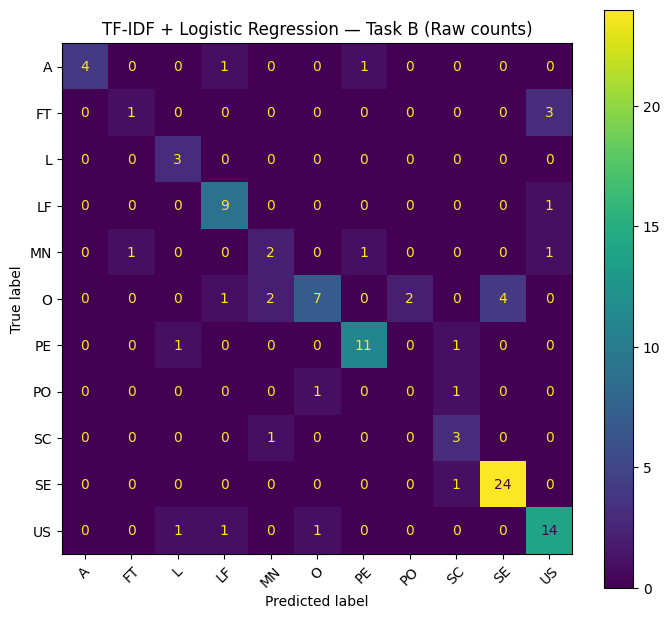

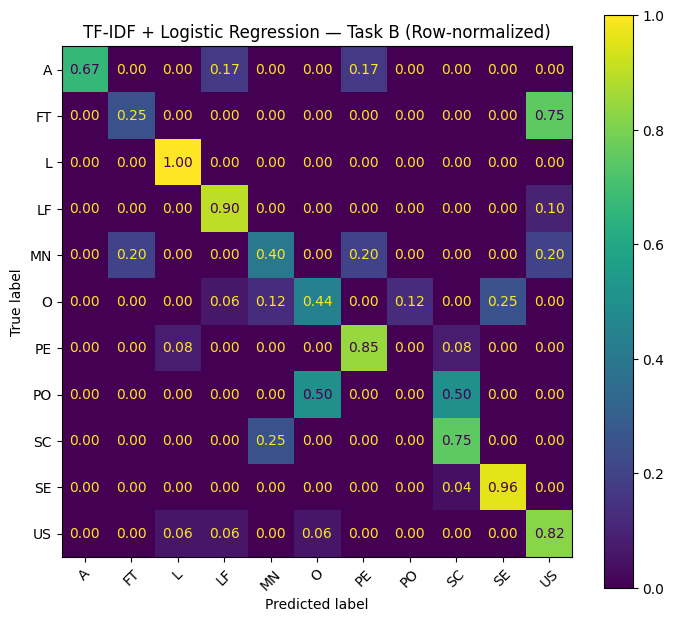

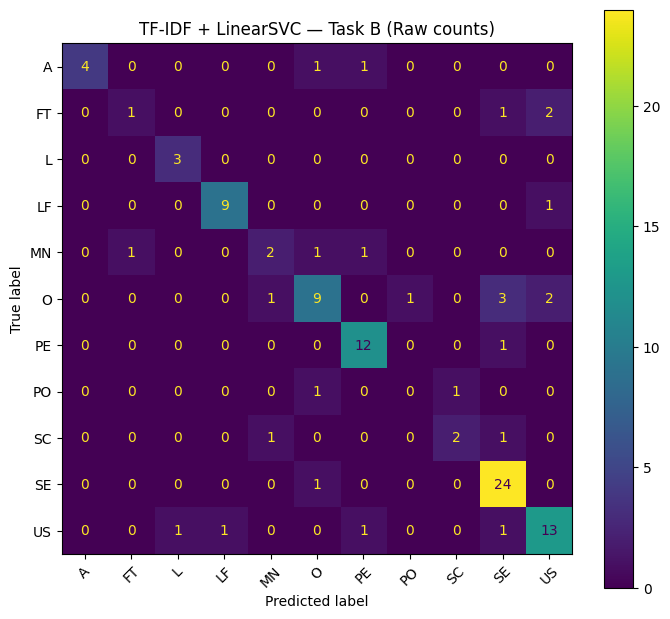

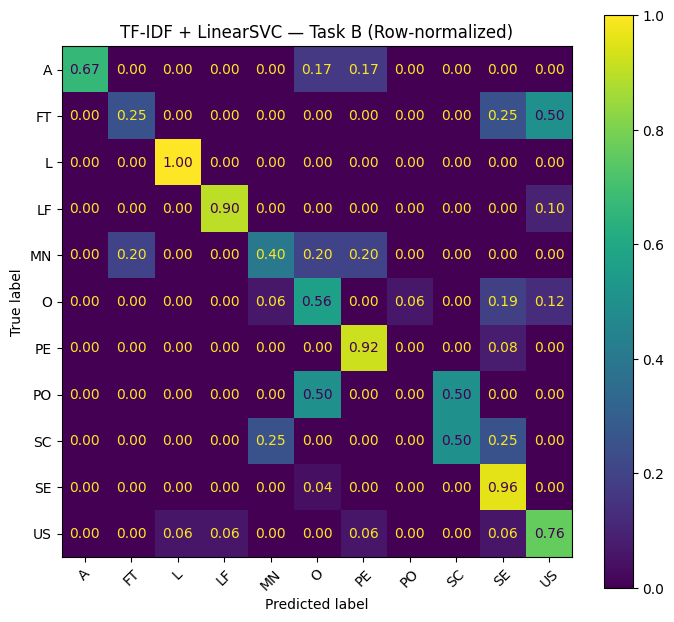

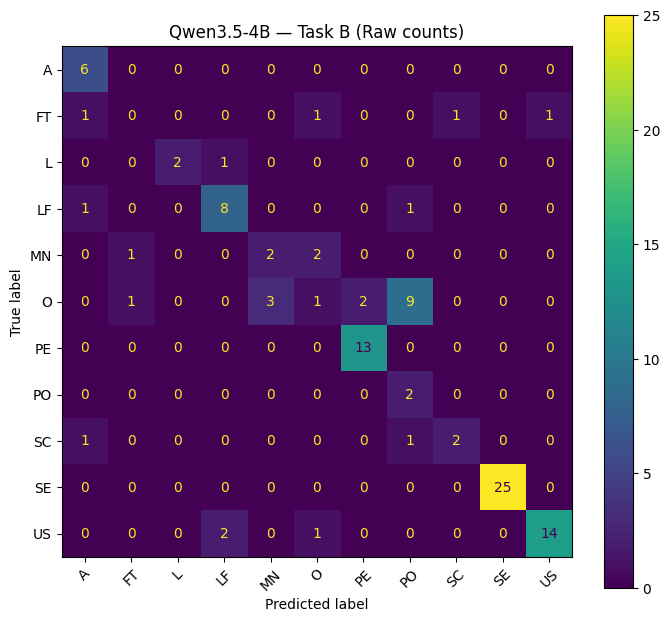

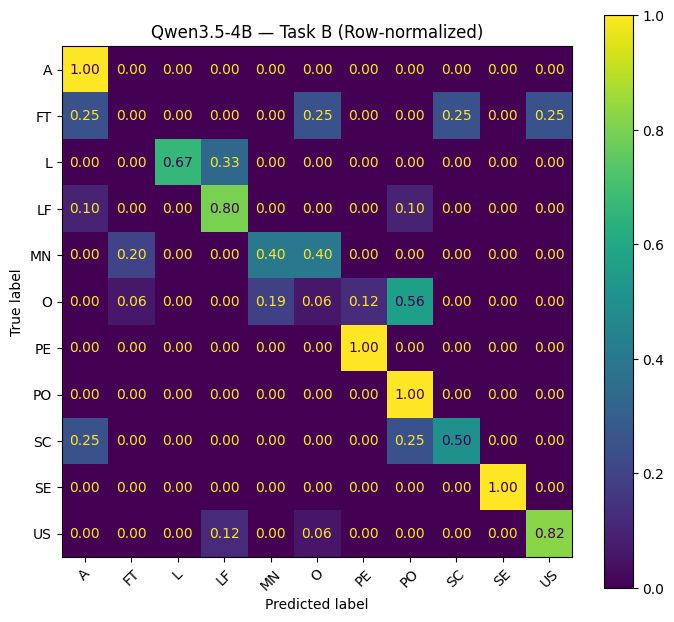

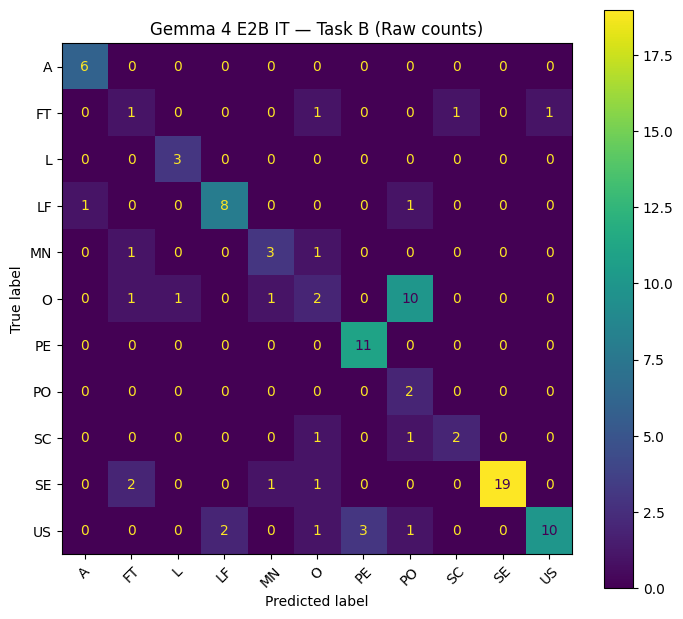

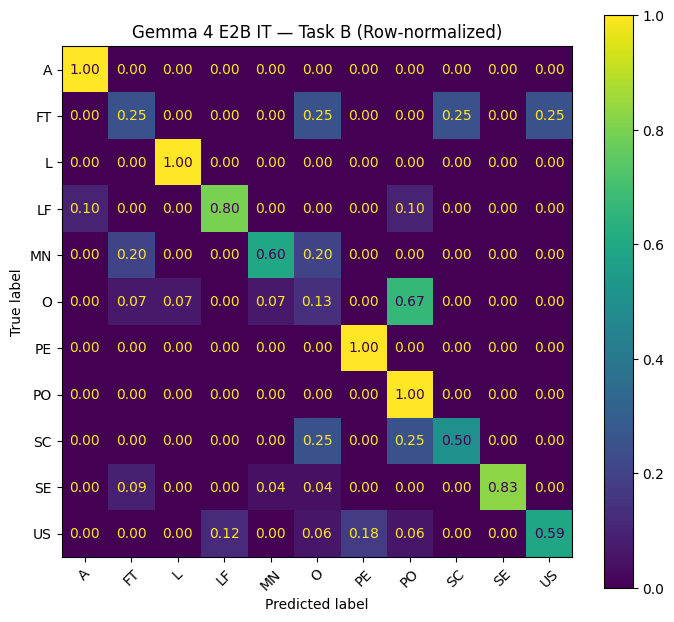

Saved confusion matrices:
- gemma_4_e2b_it_task_B_confusion_counts.pdf
- gemma_4_e2b_it_task_B_confusion_counts.png
- gemma_4_e2b_it_task_B_confusion_normalized.pdf
- gemma_4_e2b_it_task_B_confusion_normalized.png
- qwen3_5_4b_task_B_confusion_counts.pdf
- qwen3_5_4b_task_B_confusion_counts.png
- qwen3_5_4b_task_B_confusion_normalized.pdf
- qwen3_5_4b_task_B_confusion_normalized.png
- tf_idf_linearsvc_task_B_confusion_counts.pdf
- tf_idf_linearsvc_task_B_confusion_counts.png
- tf_idf_linearsvc_task_B_confusion_normalized.pdf
- tf_idf_linearsvc_task_B_confusion_normalized.png
- tf_idf_logistic_regression_task_B_confusion_counts.pdf
- tf_idf_logistic_regression_task_B_confusion_counts.png
- tf_idf_logistic_regression_task_B_confusion_normalized.pdf
- tf_idf_logistic_regression_task_B_confusion_normalized.png


In [14]:
# ============================================================
# 14) Print-ready raw and row-normalized confusion matrices
# ============================================================
def safe_filename(text):
    return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")


def save_confusion_matrices(model_name, y_true, y_pred):
    stem = safe_filename(model_name)
    for normalized in (False, True):
        matrix = confusion_matrix(
            y_true,
            y_pred,
            labels=NFR_CODES,
            normalize="true" if normalized else None,
        )
        fig, ax = plt.subplots(figsize=(7.2, 6.4))
        display_cm = ConfusionMatrixDisplay(matrix, display_labels=NFR_CODES)
        display_cm.plot(
            ax=ax,
            xticks_rotation=45,
            values_format=".2f" if normalized else "d",
            colorbar=True,
        )
        kind = "Row-normalized" if normalized else "Raw counts"
        ax.set_title(f"{model_name} — Task B ({kind})")
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        fig.tight_layout()
        suffix = "normalized" if normalized else "counts"
        fig.savefig(DIRS["figures"] / f"{stem}_task_B_confusion_{suffix}.png", dpi=300, bbox_inches="tight")
        fig.savefig(DIRS["figures"] / f"{stem}_task_B_confusion_{suffix}.pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)

for model_name, pred in predictions_b.items():
    save_confusion_matrices(model_name, y_b_true, pred)

print("Saved confusion matrices:")
for path in sorted(DIRS["figures"].glob("*confusion*")):
    print("-", path.name)

In [15]:
# ============================================================
# 15) Error analysis for triage misses, false alerts, and subtype errors
# ============================================================
def make_error_frame(model_name, eval_frame, y_true, y_pred):
    out = eval_frame[["dataset_index", "project_id", "requirement"]].copy().reset_index(drop=True)
    out["true_label"] = np.asarray(y_true)
    out["pred_label"] = np.asarray(y_pred)
    out["true_name"] = out["true_label"].map(LABEL_NAMES)
    out["pred_name"] = out["pred_label"].map(LABEL_NAMES)
    out["model"] = model_name
    out["is_error"] = out["true_label"] != out["pred_label"]
    out["is_critical_true"] = out["true_label"].isin(CRITICAL_NFR)
    out["is_critical_pred"] = out["pred_label"].isin(CRITICAL_NFR)
    out["is_correct_critical_alert"] = out["is_critical_true"] & out["is_critical_pred"]
    out["is_criticality_miss"] = out["is_critical_true"] & ~out["is_critical_pred"]
    out["is_false_critical_alert"] = ~out["is_critical_true"] & out["is_critical_pred"]
    out["is_critical_subtype_error"] = out["is_critical_true"] & out["is_error"]
    return out


all_error_frames = [
    make_error_frame(model_name, eval_b_df, y_b_true, pred)
    for model_name, pred in predictions_b.items()
]
all_errors = pd.concat(all_error_frames, ignore_index=True)
all_errors.to_csv(DIRS["errors"] / "task_B_all_predictions_and_risk_flags.csv", index=False)

critical_subtype_counts = (
    all_errors[all_errors["is_critical_true"]]
    .groupby(["model", "true_label"], as_index=False)
    .agg(Support=("true_label", "size"), Subtype_Errors=("is_critical_subtype_error", "sum"))
)
critical_subtype_counts["Subtype Error Rate"] = (
    critical_subtype_counts["Subtype_Errors"] / critical_subtype_counts["Support"]
)
critical_subtype_counts.to_csv(DIRS["errors"] / "critical_subtype_errors_by_model.csv", index=False)

criticality_miss_counts = (
    all_errors[all_errors["is_critical_true"]]
    .groupby(["model", "true_label"], as_index=False)
    .agg(Support=("true_label", "size"), Criticality_Misses=("is_criticality_miss", "sum"))
)
criticality_miss_counts["Criticality Miss Rate"] = (
    criticality_miss_counts["Criticality_Misses"] / criticality_miss_counts["Support"]
)
criticality_miss_counts.to_csv(DIRS["errors"] / "criticality_misses_by_true_class.csv", index=False)

false_alert_counts = (
    all_errors[all_errors["is_false_critical_alert"]]
    .groupby(["model", "pred_label"], as_index=False)
    .size().rename(columns={"size": "False Critical Alerts"})
)
false_alert_counts.to_csv(DIRS["errors"] / "false_critical_alerts_by_predicted_class.csv", index=False)

critical_summary_rows = []
for model_name, pred in predictions_b.items():
    critical_summary_rows.append({"Model": model_name, **critical_risk_summary(y_b_true, pred)})
critical_summary = pd.DataFrame(critical_summary_rows)
critical_summary["CMR Count"] = (
    critical_summary["Criticality Misses"].astype(str) + "/" + critical_summary["Critical True"].astype(str)
)
critical_summary["CAP Count"] = (
    critical_summary["Correct Critical Alerts"].astype(str) + "/" + critical_summary["Predicted Critical Alerts"].astype(str)
)
critical_summary["CSER Count"] = (
    critical_summary["Critical Subtype Errors"].astype(str) + "/" + critical_summary["Critical True"].astype(str)
)
critical_summary.to_csv(DIRS["errors"] / "critical_risk_summary.csv", index=False)

print("Critical-risk summary")
display(round_display(critical_summary))
print("Exact critical-subtype errors by true class")
display(round_display(critical_subtype_counts))
print("Triage-level criticality misses by true class")
display(round_display(criticality_miss_counts))
print("False critical alerts by predicted critical class")
display(round_display(false_alert_counts))


Critical-risk summary


,Model,Critical True,Predicted Critical Alerts,Correct Critical Alerts,Criticality Misses,False Critical Alerts,Critical Subtype Errors,CMR,CAP,CSER,CMR Count,CAP Count,CSER Count
0,TF-IDF + Logistic Regression,55,58,50,5,8,9,0.091,0.862,0.164,5/55,50/58,9/55
1,TF-IDF + LinearSVC,55,59,50,5,9,9,0.091,0.847,0.164,5/55,50/59,9/55
2,Qwen3.5-4B,55,56,51,4,5,7,0.073,0.911,0.127,4/55,51/56,7/55
3,Gemma 4 E2B IT,55,52,45,10,7,13,0.182,0.865,0.236,10/55,45/52,13/55


Exact critical-subtype errors by true class


,model,true_label,Support,Subtype_Errors,Subtype Error Rate
0,Gemma 4 E2B IT,A,6,0,0.000
1,Gemma 4 E2B IT,FT,4,3,0.750
2,Gemma 4 E2B IT,L,3,0,0.000
3,Gemma 4 E2B IT,PE,13,2,0.154
4,Gemma 4 E2B IT,SC,4,2,0.500
5,Gemma 4 E2B IT,SE,25,6,0.240
6,Qwen3.5-4B,A,6,0,0.000
7,Qwen3.5-4B,FT,4,4,1.000
8,Qwen3.5-4B,L,3,1,0.333
9,Qwen3.5-4B,PE,13,0,0.000


Triage-level criticality misses by true class


,model,true_label,Support,Criticality_Misses,Criticality Miss Rate
0,Gemma 4 E2B IT,A,6,0,0.000
1,Gemma 4 E2B IT,FT,4,2,0.500
2,Gemma 4 E2B IT,L,3,0,0.000
3,Gemma 4 E2B IT,PE,13,2,0.154
4,Gemma 4 E2B IT,SC,4,2,0.500
5,Gemma 4 E2B IT,SE,25,4,0.160
6,Qwen3.5-4B,A,6,0,0.000
7,Qwen3.5-4B,FT,4,2,0.500
8,Qwen3.5-4B,L,3,1,0.333
9,Qwen3.5-4B,PE,13,0,0.000


False critical alerts by predicted critical class


,model,pred_label,False Critical Alerts
0,Gemma 4 E2B IT,A,1
1,Gemma 4 E2B IT,FT,2
2,Gemma 4 E2B IT,L,1
3,Gemma 4 E2B IT,PE,3
4,Qwen3.5-4B,A,1
5,Qwen3.5-4B,FT,2
6,Qwen3.5-4B,PE,2
7,TF-IDF + LinearSVC,FT,1
8,TF-IDF + LinearSVC,L,1
9,TF-IDF + LinearSVC,PE,2


## Manuscript-facing revision text

### Construct definitions

- **CMR** is a triage-level false-negative rate: a true critical requirement is counted as missed only when the prediction is outside the critical set.
- **CAP** measures the false-alarm side: the proportion of predicted critical alerts that are truly critical.
- **CSER** is the exact critical-subtype error rate. A critical requirement predicted as a different critical subtype is an error for CSER but not a miss for CMR.

### Statistical-power threat

The held-out Task B sample is small and several NFR subtypes are rare. Consequently, small differences in CMR, CAP, CSER, or RWE may correspond to only one or two requirements. The analysis reports absolute numerators and denominators, per-class support, paired stratified bootstrap confidence intervals, paired model differences, and bootstrap rank stability. Equal bootstrap winners receive equal fractional credit.

### RWE interpretation and limitation

The 3-2-1 and 5-3-1 values are author-proposed project-criticality weights, not ground-truth risk labels. RWE uses only the **true class** to choose the penalty; every wrong destination for that true class receives the same cost. Therefore, a critical-to-critical confusion and a critical-to-noncritical confusion receive the same RWE weight. RWE is a simplifying severity-weighted error, not a complete pairwise stakeholder cost matrix.

### Model-comparison caveat

Qwen3.5-4B and Gemma 4 E2B IT are not parameter- or architecture-matched. This notebook provides a practical comparison of deployable checkpoints rather than a controlled architecture-family or equal-capacity experiment.

### Benchmark-contamination threat

PROMISE_exp is a public, long-standing benchmark, while the complete pretraining and post-training corpora of the evaluated LLMs are not disclosed. Requirements or closely related benchmark material may therefore have appeared during training. The LLM results must not be interpreted as guaranteed contamination-free generalization.

### Defensible framing

Risk-aware metrics **complement, not replace**, accuracy, F1, per-class results, and confusion matrices. Model-preference language should refer to point estimates when confidence intervals overlap or rank stability is weak.

### Data/code availability template

> The complete reproducibility package contains the exact PROMISE_exp snapshot and checksum, split indices, Task B training/test supports, explicit baseline and LLM configurations, prompts and demonstration audit, raw/visible/normalized outputs, strict parsing logs, bootstrap code and outputs, table/figure generation code, and an executable source snapshot. The permanent repository URL and archived DOI must be inserted only after a public tagged release and clean-environment reproduction check.


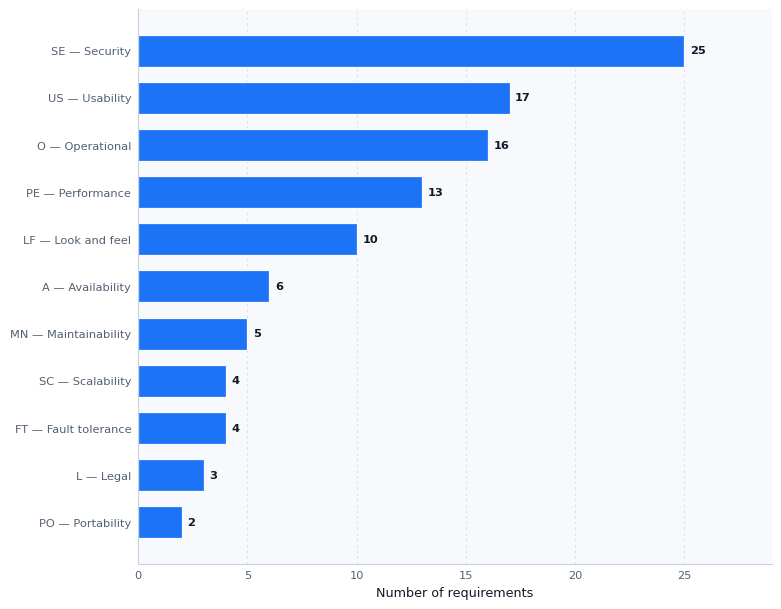

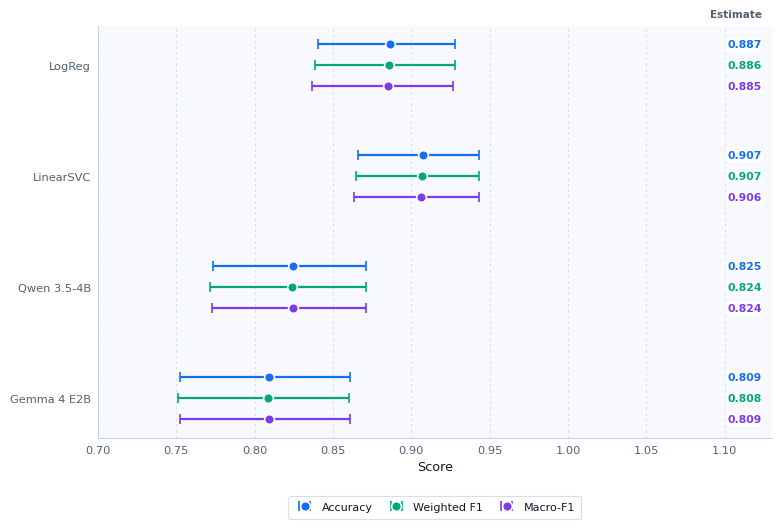

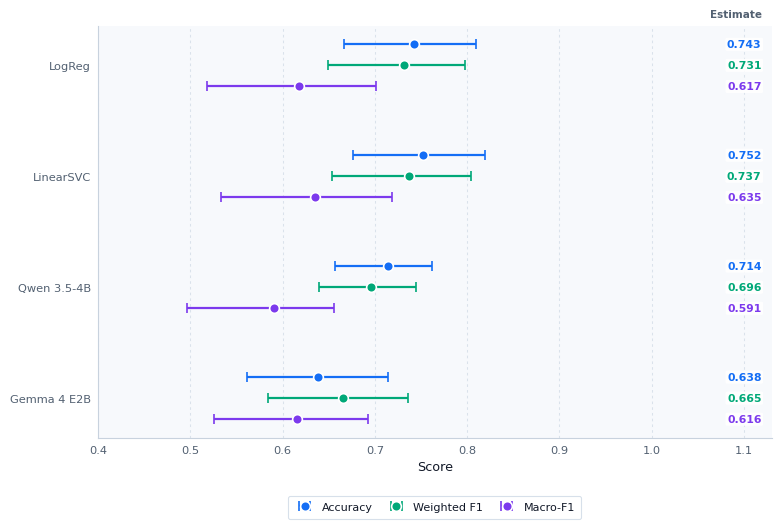

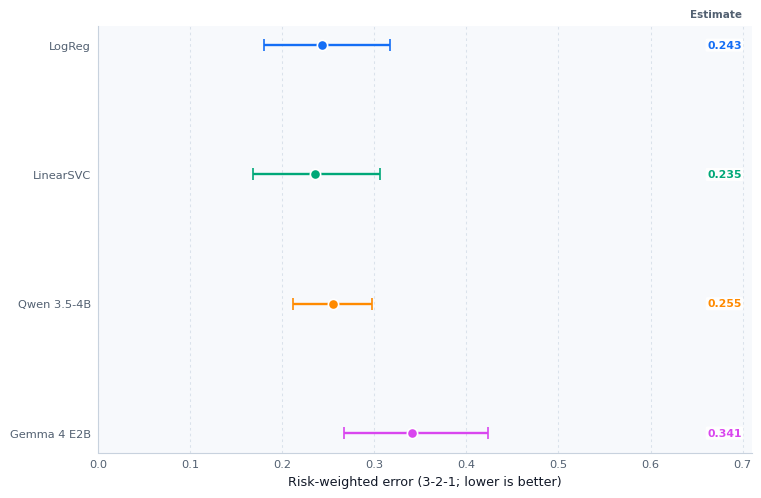

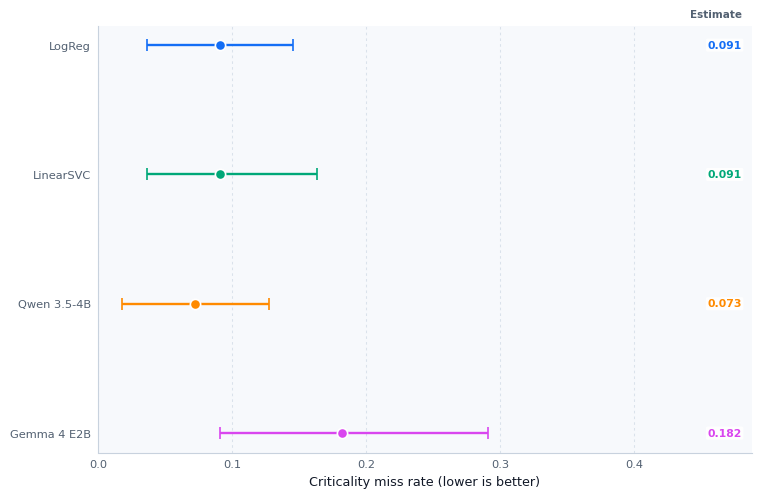

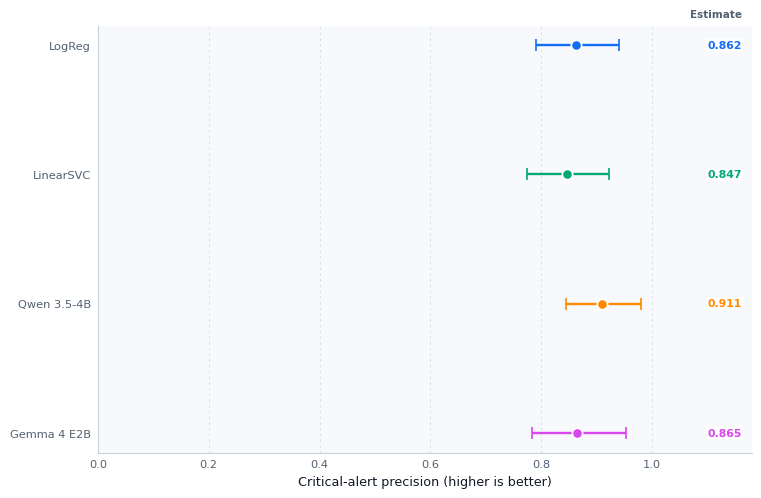

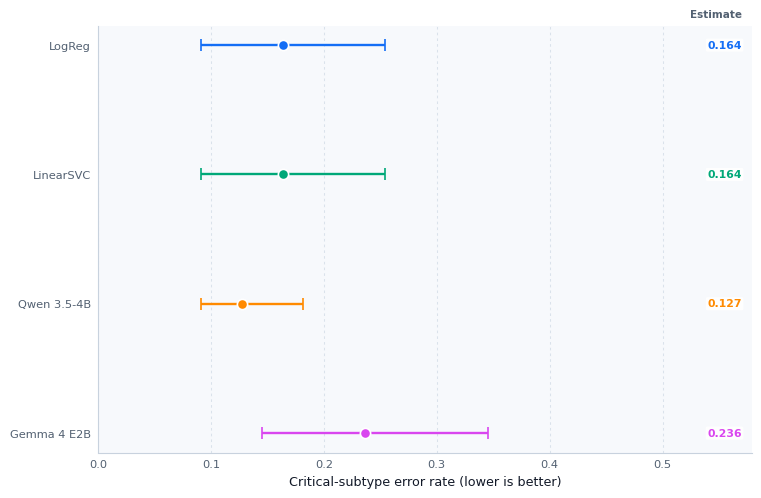

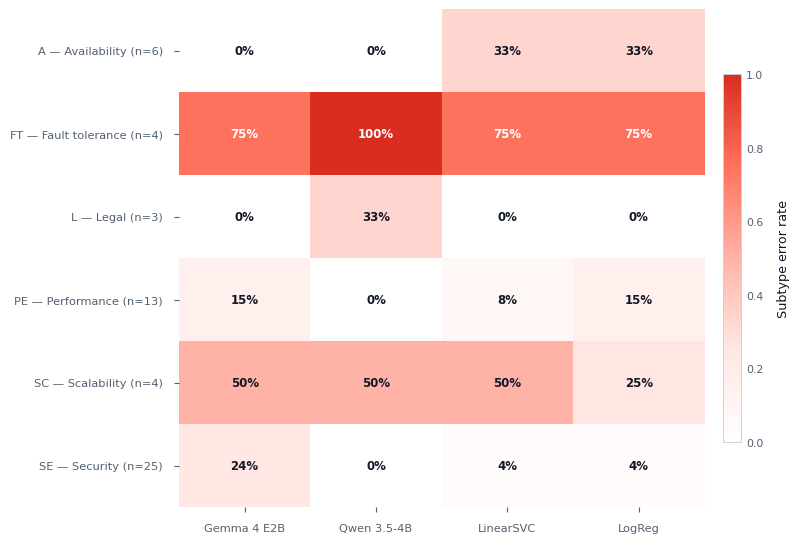

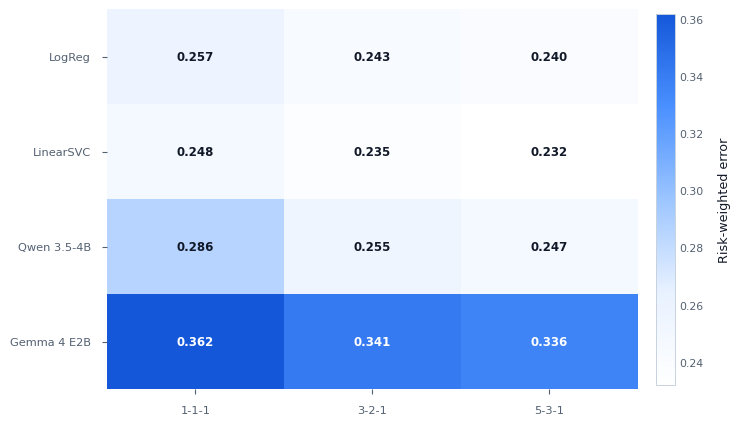

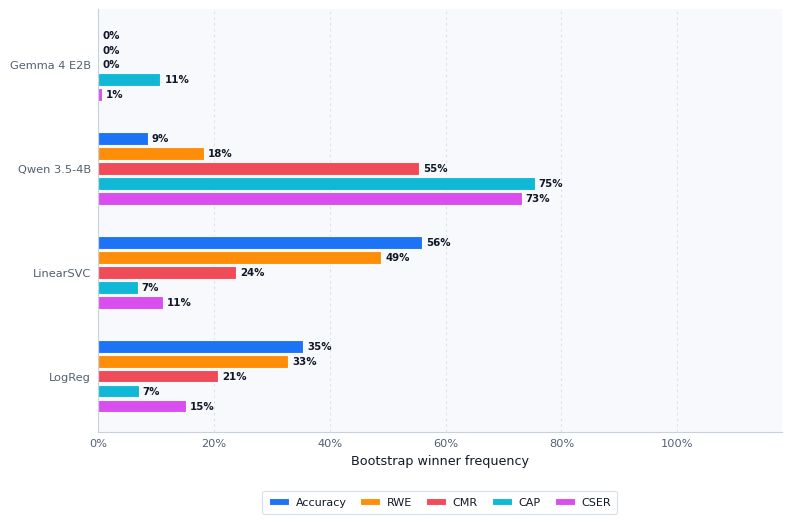

Created 10 publication figures in:
/kaggle/working/rwe_revision_results/article_figures
- figure_task_B_test_class_distribution.png
- figure_task_B_test_class_distribution.pdf
- figure_task_B_test_class_distribution.svg
- figure_task_A_metrics_with_95ci.png
- figure_task_A_metrics_with_95ci.pdf
- figure_task_A_metrics_with_95ci.svg
- figure_task_B_metrics_with_95ci.png
- figure_task_B_metrics_with_95ci.pdf
- figure_task_B_metrics_with_95ci.svg
- figure_task_B_RWE_with_95ci.png
- figure_task_B_RWE_with_95ci.pdf
- figure_task_B_RWE_with_95ci.svg
- figure_task_B_CMR_with_95ci.png
- figure_task_B_CMR_with_95ci.pdf
- figure_task_B_CMR_with_95ci.svg
- figure_task_B_CAP_with_95ci.png
- figure_task_B_CAP_with_95ci.pdf
- figure_task_B_CAP_with_95ci.svg
- figure_task_B_CSER_with_95ci.png
- figure_task_B_CSER_with_95ci.pdf
- figure_task_B_CSER_with_95ci.svg
- figure_critical_subtype_error_rates.png
- figure_critical_subtype_error_rates.pdf
- figure_critical_subtype_error_rates.svg
- figure_RWE_we

In [16]:
# ============================================================
# Publication-ready article figures — modern light v4
# ============================================================
from pathlib import Path
from textwrap import fill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.colors import LinearSegmentedColormap, Normalize
from cycler import cycler

# -----------------------------
# User-facing configuration
# -----------------------------
SHOW_PLOT_TITLES = False
# For journal articles, keep this False and use the exported captions below the figures.
# Set it to True only for presentations or standalone reports.

EXPORT_FORMATS = ("png", "pdf", "svg")
PNG_DPI = 300

# -----------------------------
# Paths and saved-result loading
# -----------------------------
if "DIRS" in globals():
    RESULTS_DIR = Path(DIRS["root"])
else:
    RESULTS_DIR = Path("/kaggle/working/rwe_revision_results")

# Separate folder requested for final manuscript artwork.
ARTICLE_FIGURE_DIR = RESULTS_DIR / "article_figures"
ARTICLE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def load_frame(variable_name, relative_path):
    """Use an existing DataFrame when available; otherwise read its saved CSV."""
    value = globals().get(variable_name)
    if isinstance(value, pd.DataFrame):
        return value.copy()

    path = RESULTS_DIR / relative_path
    if not path.exists():
        raise FileNotFoundError(
            f"Required result was not found: {path}\n"
            "Run the prediction, bootstrap, table, and error-analysis cells first."
        )
    return pd.read_csv(path)


bootstrap_plot = load_frame(
    "bootstrap_summary",
    "bootstrap/bootstrap_summary.csv",
)
rank_plot = load_frame(
    "rank_stability",
    "bootstrap/task_B_rank_stability.csv",
)
critical_plot = load_frame(
    "critical_subtype_counts",
    "error_analysis/critical_subtype_errors_by_model.csv",
)
support_plot = load_frame(
    "test_nfr_support",
    "metrics/task_b_test_class_support.csv",
)
weight_plot = load_frame(
    "table_V",
    "tables/table_V_weight_sensitivity_rank_stability.csv",
)

# -----------------------------
# Compact labels and vivid palette
# -----------------------------
MODEL_SHORT = {
    "TF-IDF + Logistic Regression": "LogReg",
    "TF-IDF + LinearSVC": "LinearSVC",
    "Qwen3.5-4B": "Qwen 3.5-4B",
    "Gemma 4 E2B IT": "Gemma 4 E2B",
}

NFR_NAMES = {
    "A": "Availability",
    "FT": "Fault tolerance",
    "L": "Legal",
    "PE": "Performance",
    "SC": "Scalability",
    "SE": "Security",
    "LF": "Look and feel",
    "MN": "Maintainability",
    "O": "Operational",
    "PO": "Portability",
    "US": "Usability",
}

COLOR = {
    "figure_bg": "#FFFFFF",
    "axes_bg": "#F7F9FC",
    "text": "#111827",
    "muted_text": "#526071",
    "grid": "#D7E0EA",
    "spine": "#C8D2DE",
    "blue": "#146EF5",
    "green": "#00A878",
    "orange": "#FF8A00",
    "magenta": "#D946EF",
    "purple": "#7C3AED",
    "red": "#F04452",
    "cyan": "#06B6D4",
}

# The same model keeps the same color in every figure.
MODEL_COLORS = {
    "TF-IDF + Logistic Regression": COLOR["blue"],
    "TF-IDF + LinearSVC": COLOR["green"],
    "Qwen3.5-4B": COLOR["orange"],
    "Gemma 4 E2B IT": COLOR["magenta"],
}

METRIC_COLORS = {
    "Accuracy": COLOR["blue"],
    "Weighted F1": COLOR["green"],
    "Macro-F1": COLOR["purple"],
    "RWE": COLOR["orange"],
    "CMR": COLOR["red"],
    "CAP": COLOR["cyan"],
    "CSER": COLOR["magenta"],
}

RANK_COLORS = {
    "Accuracy": COLOR["blue"],
    "RWE": COLOR["orange"],
    "CMR": COLOR["red"],
    "CAP": COLOR["cyan"],
    "CSER": COLOR["magenta"],
}

FALLBACK_COLORS = [
    COLOR["blue"], COLOR["green"], COLOR["orange"], COLOR["magenta"],
    COLOR["purple"], COLOR["red"], COLOR["cyan"], "#64748B",
]

# Sequential heatmaps retain readable contrast on white paper.
MISS_CMAP = LinearSegmentedColormap.from_list(
    "miss_rate_vivid",
    ["#FFFFFF", "#FFE7E3", "#FFB3A7", "#FF725E", "#D92D20"],
)
RWE_CMAP = LinearSegmentedColormap.from_list(
    "rwe_vivid",
    ["#FFFFFF", "#E8F1FF", "#9CC5FF", "#4A90FF", "#1457D9"],
)

CREATED_FIGURES = []

# -----------------------------
# Suggested captions for the paper
# -----------------------------
FIGURE_CAPTIONS = {
    "figure_task_B_test_class_distribution": (
        "Distribution of NFR classes in the held-out Task B test set. "
        "Values at the end of the bars report the number of requirements in each class."
    ),
    "figure_task_A_metrics_with_95ci": (
        "Task A model performance with uncertainty. Points show point estimates, horizontal "
        "whiskers show 95% paired stratified bootstrap confidence intervals, and labels report "
        "the point estimates."
    ),
    "figure_task_B_metrics_with_95ci": (
        "Task B model performance with uncertainty. Points show point estimates, horizontal "
        "whiskers show 95% paired stratified bootstrap confidence intervals, and labels report "
        "the point estimates."
    ),
    "figure_task_B_RWE_with_95ci": (
        "Task B risk-weighted error under the 3-2-1 weighting scheme. Points show estimates and "
        "horizontal whiskers show 95% paired stratified bootstrap confidence intervals; lower is better."
    ),
    "figure_task_B_CMR_with_95ci": (
        "Task B triage-level criticality miss rate. Points show estimates and horizontal whiskers show "
        "95% paired stratified bootstrap confidence intervals; lower is better."
    ),
    "figure_task_B_CAP_with_95ci": (
        "Task B critical-alert precision. Points show estimates and horizontal whiskers show 95% paired "
        "stratified bootstrap confidence intervals; higher is better."
    ),
    "figure_task_B_CSER_with_95ci": (
        "Task B exact critical-subtype error rate. Points show estimates and horizontal whiskers show 95% paired "
        "stratified bootstrap confidence intervals; lower is better."
    ),
    "figure_critical_subtype_error_rates": (
        "Model exact subtype-error rates within the six critical NFR classes. Cell annotations report percentages, "
        "and class labels include the held-out support size."
    ),
    "figure_RWE_weight_sensitivity": (
        "Risk-weighted error sensitivity across the 1-1-1, 3-2-1, and 5-3-1 weighting schemes. "
        "Cell annotations report RWE values; lower values indicate better performance."
    ),
    "figure_task_B_bootstrap_rank_stability": (
        "Task B ranking stability across paired stratified bootstrap replicates. Bars report the "
        "proportion of replicates in which each model achieved the best value for the stated metric."
    ),
}

# -----------------------------
# Modern light matplotlib theme
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans", "sans-serif"],
    "font.size": 9,
    "font.weight": "regular",
    "text.color": COLOR["text"],
    "axes.labelcolor": COLOR["text"],
    "axes.titlecolor": COLOR["text"],
    "axes.titlesize": 10.5,
    "axes.titleweight": "semibold",
    "axes.labelsize": 9.2,
    "axes.facecolor": COLOR["axes_bg"],
    "figure.facecolor": COLOR["figure_bg"],
    "savefig.facecolor": COLOR["figure_bg"],
    "xtick.color": COLOR["muted_text"],
    "ytick.color": COLOR["muted_text"],
    "xtick.labelsize": 8.2,
    "ytick.labelsize": 8.2,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8.2,
    "axes.edgecolor": COLOR["spine"],
    "axes.linewidth": 0.8,
    "grid.color": COLOR["grid"],
    "grid.linewidth": 0.75,
    "grid.alpha": 0.9,
    "grid.linestyle": (0, (2.5, 3.0)),
    "lines.linewidth": 2.1,
    "lines.markersize": 6.5,
    "patch.edgecolor": COLOR["figure_bg"],
    "patch.linewidth": 0.8,
    "axes.prop_cycle": cycler(color=FALLBACK_COLORS),
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def short_model(name):
    return MODEL_SHORT.get(str(name), str(name))


def model_color(name, index=0):
    return MODEL_COLORS.get(str(name), FALLBACK_COLORS[index % len(FALLBACK_COLORS)])


def wrapped(text, width=38):
    return fill(str(text), width=width, break_long_words=False)


def new_figure(figsize):
    """Create a light figure with overlap-aware layout."""
    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    fig.patch.set_facecolor(COLOR["figure_bg"])
    ax.set_facecolor(COLOR["axes_bg"])
    return fig, ax


def style_axis(ax, grid_axis="x"):
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis)
    ax.grid(axis="y" if grid_axis == "x" else "x", visible=False)

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(COLOR["spine"])
        ax.spines[side].set_linewidth(0.8)

    ax.tick_params(axis="both", which="both", length=0, pad=5)


def maybe_title(ax, title, width=58):
    """Article figures normally omit plot titles; captions carry the explanation."""
    if SHOW_PLOT_TITLES:
        ax.set_title(wrapped(title, width), loc="left", pad=11, fontweight="semibold")


def legend_below(ax, ncol=2, y=-0.16):
    legend = ax.legend(
        frameon=True,
        fancybox=True,
        ncol=max(1, ncol),
        loc="upper center",
        bbox_to_anchor=(0.5, y),
        borderaxespad=0.0,
        handlelength=1.8,
        handletextpad=0.6,
        columnspacing=1.25,
        borderpad=0.6,
    )
    if legend is not None:
        frame = legend.get_frame()
        frame.set_facecolor(COLOR["figure_bg"])
        frame.set_edgecolor(COLOR["grid"])
        frame.set_linewidth(0.8)
        frame.set_alpha(1.0)
    return legend


def save_publication_figure(fig, stem):
    """Save high-resolution raster and vector versions before displaying."""
    outputs = []
    for extension in EXPORT_FORMATS:
        path = ARTICLE_FIGURE_DIR / f"{stem}.{extension}"
        if extension == "png":
            fig.savefig(path, dpi=PNG_DPI, bbox_inches="tight", pad_inches=0.10)
        else:
            fig.savefig(path, bbox_inches="tight", pad_inches=0.10)
        outputs.append(path)

    CREATED_FIGURES.extend(outputs)
    plt.show()
    plt.close(fig)


def ci_frame(task, metrics):
    frame = bootstrap_plot.copy()
    frame["Task"] = frame["Task"].astype(str)
    frame = frame[
        (frame["Task"] == str(task)) &
        (frame["Metric"].isin(metrics))
    ].copy()
    if frame.empty:
        raise ValueError(f"No bootstrap rows found for Task {task}: {metrics}")
    return frame


def add_right_value_column(ax, y_positions, values, formatter, header="Estimate", colors=None):
    """Place values in a fixed right-side column so they never overlap whiskers/bars."""
    transform = ax.get_yaxis_transform()  # x in axes coordinates, y in data coordinates
    if colors is None:
        colors = [COLOR["text"]] * len(values)
    elif isinstance(colors, str):
        colors = [colors] * len(values)
    for y_value, value, text_color in zip(y_positions, values, colors):
        ax.text(
            0.985,
            y_value,
            formatter(value),
            transform=transform,
            ha="right",
            va="center",
            fontsize=7.8,
            color=text_color,
            fontweight="semibold",
            bbox={
                "boxstyle": "round,pad=0.14",
                "facecolor": COLOR["figure_bg"],
                "edgecolor": "none",
                "alpha": 0.94,
            },
            zorder=5,
            clip_on=False,
        )
    ax.text(
        0.985,
        1.015,
        header,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=7.5,
        color=COLOR["muted_text"],
        fontweight="semibold",
        clip_on=False,
    )


def plot_grouped_metrics_with_ci(task, metrics, title, stem):
    """Horizontal dot-and-whisker plot with a dedicated numerical-value column."""
    frame = ci_frame(task, metrics)
    models = frame["Model"].drop_duplicates().tolist()
    y = np.arange(len(models), dtype=float)
    offset_step = 0.19 if len(metrics) <= 3 else 0.68 / len(metrics)

    all_lows = pd.to_numeric(frame["CI Low"], errors="raise").to_numpy(dtype=float)
    x_min = max(0.0, np.floor((np.nanmin(all_lows) - 0.05) * 10) / 10)
    x_max = 1.13  # room for the right-side value column

    fig, ax = new_figure((7.7, max(4.6, 0.82 * len(models) + 1.9)))

    for metric_index, metric in enumerate(metrics):
        metric_rows = (
            frame[frame["Metric"] == metric]
            .set_index("Model")
            .reindex(models)
        )
        estimates = metric_rows["Estimate"].to_numpy(dtype=float)
        ci_low = metric_rows["CI Low"].to_numpy(dtype=float)
        ci_high = metric_rows["CI High"].to_numpy(dtype=float)
        lower = np.maximum(estimates - ci_low, 0)
        upper = np.maximum(ci_high - estimates, 0)
        offsets = (metric_index - (len(metrics) - 1) / 2) * offset_step
        positions = y + offsets
        color = METRIC_COLORS.get(metric, FALLBACK_COLORS[metric_index])

        ax.errorbar(
            estimates,
            positions,
            xerr=np.vstack([lower, upper]),
            fmt="o",
            markersize=7.0,
            markerfacecolor=color,
            markeredgecolor=COLOR["figure_bg"],
            markeredgewidth=1.2,
            ecolor=color,
            color=color,
            capsize=3.5,
            capthick=1.3,
            elinewidth=1.6,
            label=metric,
            zorder=3,
        )
        add_right_value_column(
            ax,
            positions,
            estimates,
            formatter=lambda value: f"{value:.3f}",
            header="Estimate" if metric_index == 0 else "",
            colors=color,
        )

    ax.set_yticks(y, [short_model(model) for model in models])
    ax.invert_yaxis()
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Score")
    maybe_title(ax, title)
    style_axis(ax, grid_axis="x")
    legend_below(ax, ncol=len(metrics), y=-0.14)
    save_publication_figure(fig, stem)


def plot_single_metric_with_ci(metric, title, stem, xlabel):
    """Model-colored point estimate and 95% CI with a separate value column."""
    frame = ci_frame("B", [metric])
    models = frame["Model"].drop_duplicates().tolist()
    rows = frame.set_index("Model").reindex(models)

    estimates = rows["Estimate"].to_numpy(dtype=float)
    ci_low = rows["CI Low"].to_numpy(dtype=float)
    ci_high = rows["CI High"].to_numpy(dtype=float)
    y = np.arange(len(models), dtype=float)

    max_high = float(np.nanmax(ci_high)) if len(ci_high) else 0.1
    x_max = min(1.0, max(0.12, max_high * 1.42))
    # Add a protected right-side label column without compressing the CI region.
    plot_x_max = x_max * 1.18

    fig, ax = new_figure((7.5, max(4.25, 0.78 * len(models) + 1.75)))

    for index, (model, estimate, low, high, yi) in enumerate(
        zip(models, estimates, ci_low, ci_high, y)
    ):
        color = model_color(model, index)
        lower = max(float(estimate - low), 0)
        upper = max(float(high - estimate), 0)
        ax.errorbar(
            estimate,
            yi,
            xerr=np.array([[lower], [upper]]),
            fmt="o",
            markersize=7.4,
            markerfacecolor=color,
            markeredgecolor=COLOR["figure_bg"],
            markeredgewidth=1.2,
            ecolor=color,
            color=color,
            capsize=4,
            capthick=1.3,
            elinewidth=1.7,
            zorder=3,
        )

    add_right_value_column(
        ax,
        y,
        estimates,
        formatter=lambda value: f"{value:.3f}",
        header="Estimate",
        colors=[model_color(model, index) for index, model in enumerate(models)],
    )

    ax.set_yticks(y, [short_model(model) for model in models])
    ax.invert_yaxis()
    ax.set_xlim(0, plot_x_max)
    ax.set_xlabel(xlabel)
    maybe_title(ax, title)
    style_axis(ax, grid_axis="x")
    save_publication_figure(fig, stem)


def annotated_heatmap(
    matrix,
    row_labels,
    column_labels,
    cmap,
    colorbar_label,
    formatter,
    stem,
    title,
    figsize,
    vmin=None,
    vmax=None,
):
    """Create an uncluttered annotated heatmap for dense numerical comparisons."""
    matrix = np.asarray(matrix, dtype=float)
    if vmin is None:
        vmin = float(np.nanmin(matrix))
    if vmax is None:
        vmax = float(np.nanmax(matrix))
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-9

    fig, ax = new_figure(figsize)
    image = ax.imshow(matrix, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.grid(False)

    ax.set_xticks(np.arange(len(column_labels)), column_labels)
    ax.set_yticks(np.arange(len(row_labels)), row_labels)
    ax.tick_params(axis="x", labelrotation=0, pad=8)
    ax.tick_params(axis="y", pad=8)

    norm = Normalize(vmin=vmin, vmax=vmax)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            if np.isnan(value):
                label = "—"
                text_color = COLOR["muted_text"]
            else:
                label = formatter(value)
                text_color = "#FFFFFF" if norm(value) > 0.58 else COLOR["text"]
            ax.text(
                column_index,
                row_index,
                label,
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="semibold",
                color=text_color,
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.035)
    colorbar.set_label(colorbar_label, rotation=90, labelpad=10)
    colorbar.outline.set_edgecolor(COLOR["spine"])
    colorbar.outline.set_linewidth(0.7)
    colorbar.ax.tick_params(labelsize=7.8, length=0)

    maybe_title(ax, title)
    save_publication_figure(fig, stem)


# --------------------------------------------------
# Figure 1 — Task B held-out class distribution
# --------------------------------------------------
support_rows = support_plot.copy()
support_rows["count"] = pd.to_numeric(support_rows["count"], errors="raise")
support_rows["display_label"] = support_rows.apply(
    lambda row: f"{row['label']} — {NFR_NAMES.get(row['label'], row.get('label_name', row['label']))}",
    axis=1,
)
support_rows = support_rows.sort_values("count", ascending=True)

fig, ax = new_figure((7.7, max(5.2, 0.43 * len(support_rows) + 1.25)))
bars = ax.barh(
    support_rows["display_label"],
    support_rows["count"],
    color=COLOR["blue"],
    alpha=0.96,
    edgecolor=COLOR["figure_bg"],
    linewidth=0.9,
    height=0.68,
)
max_count = float(support_rows["count"].max()) if len(support_rows) else 1.0
ax.set_xlim(0, max_count * 1.16)
ax.bar_label(
    bars,
    labels=[f"{int(value)}" for value in support_rows["count"]],
    padding=4,
    fontsize=8.2,
    color=COLOR["text"],
    fontweight="semibold",
)
ax.set_xlabel("Number of requirements")
maybe_title(ax, "Task B test-set class distribution")
style_axis(ax, grid_axis="x")
save_publication_figure(fig, "figure_task_B_test_class_distribution")

# --------------------------------------------------
# Figures 2–3 — Conventional metrics with uncertainty
# --------------------------------------------------
plot_grouped_metrics_with_ci(
    task="A",
    metrics=["Accuracy", "Weighted F1", "Macro-F1"],
    title="Task A performance with 95% bootstrap confidence intervals",
    stem="figure_task_A_metrics_with_95ci",
)

plot_grouped_metrics_with_ci(
    task="B",
    metrics=["Accuracy", "Weighted F1", "Macro-F1"],
    title="Task B performance with 95% bootstrap confidence intervals",
    stem="figure_task_B_metrics_with_95ci",
)

# --------------------------------------------------
# Figures 4–5 — Risk-aware metrics with uncertainty
# --------------------------------------------------
plot_single_metric_with_ci(
    metric="RWE",
    title="Task B risk-weighted error with 95% bootstrap confidence intervals",
    stem="figure_task_B_RWE_with_95ci",
    xlabel="Risk-weighted error (3-2-1; lower is better)",
)

plot_single_metric_with_ci(
    metric="CMR",
    title="Task B criticality miss rate with 95% bootstrap confidence intervals",
    stem="figure_task_B_CMR_with_95ci",
    xlabel="Criticality miss rate (lower is better)",
)

plot_single_metric_with_ci(
    metric="CAP",
    title="Task B critical-alert precision with 95% bootstrap confidence intervals",
    stem="figure_task_B_CAP_with_95ci",
    xlabel="Critical-alert precision (higher is better)",
)

plot_single_metric_with_ci(
    metric="CSER",
    title="Task B critical-subtype error rate with 95% bootstrap confidence intervals",
    stem="figure_task_B_CSER_with_95ci",
    xlabel="Critical-subtype error rate (lower is better)",
)

# --------------------------------------------------
# Figure 6 — Critical-class miss-rate heatmap
# --------------------------------------------------
critical_rows = critical_plot.copy()
critical_rows["Subtype Error Rate"] = pd.to_numeric(critical_rows["Subtype Error Rate"], errors="raise")
critical_order = [
    code for code in ["A", "FT", "L", "PE", "SC", "SE"]
    if code in set(critical_rows["true_label"])
]
models = critical_rows["model"].drop_duplicates().tolist()
support_by_class = critical_rows.groupby("true_label")["Support"].max().to_dict()

critical_matrix = (
    critical_rows
    .pivot_table(index="true_label", columns="model", values="Subtype Error Rate", aggfunc="first")
    .reindex(index=critical_order, columns=models)
    .to_numpy(dtype=float)
)
critical_row_labels = [
    f"{code} — {NFR_NAMES.get(code, code)} (n={int(support_by_class.get(code, 0))})"
    for code in critical_order
]
critical_column_labels = [short_model(model) for model in models]

annotated_heatmap(
    matrix=critical_matrix,
    row_labels=critical_row_labels,
    column_labels=critical_column_labels,
    cmap=MISS_CMAP,
    colorbar_label="Subtype error rate",
    formatter=lambda value: f"{value:.0%}",
    stem="figure_critical_subtype_error_rates",
    title="Exact subtype-error rates within critical NFR classes",
    figsize=(7.9, max(4.5, 0.62 * len(critical_order) + 1.6)),
    vmin=0.0,
    vmax=max(1.0, float(np.nanmax(critical_matrix))),
)

# --------------------------------------------------
# Figure 7 — RWE sensitivity heatmap
# --------------------------------------------------
weight_columns = ["RWE 1-1-1", "RWE 3-2-1", "RWE 5-3-1"]
missing_weight_columns = [column for column in weight_columns if column not in weight_plot.columns]
if missing_weight_columns:
    raise KeyError(f"Missing weight-sensitivity columns: {missing_weight_columns}")

weight_matrix = weight_plot[weight_columns].to_numpy(dtype=float)
weight_row_labels = [short_model(model) for model in weight_plot["Model"]]
weight_column_labels = ["1-1-1", "3-2-1", "5-3-1"]

annotated_heatmap(
    matrix=weight_matrix,
    row_labels=weight_row_labels,
    column_labels=weight_column_labels,
    cmap=RWE_CMAP,
    colorbar_label="Risk-weighted error",
    formatter=lambda value: f"{value:.3f}",
    stem="figure_RWE_weight_sensitivity",
    title="Robustness of model rankings across risk-weighting schemes",
    figsize=(7.3, max(4.0, 0.66 * len(weight_row_labels) + 1.5)),
)

# --------------------------------------------------
# Figure 8 — Bootstrap rank stability
# --------------------------------------------------
rank_metrics = [
    ("Winner Frequency — Accuracy", "Accuracy"),
    ("Winner Frequency — RWE", "RWE"),
    ("Winner Frequency — CMR", "CMR"),
    ("Winner Frequency — CAP", "CAP"),
    ("Winner Frequency — CSER", "CSER"),
]
existing_rank_metrics = [
    (column, label) for column, label in rank_metrics
    if column in rank_plot.columns
]
if not existing_rank_metrics:
    raise KeyError("No winner-frequency columns were found in task_B_rank_stability.csv")

models = rank_plot["Model"].tolist()
y = np.arange(len(models), dtype=float)
height = 0.72 / len(existing_rank_metrics)
fig, ax = new_figure((7.8, max(4.8, 0.82 * len(models) + 1.85)))
containers = []
for metric_index, (column, label) in enumerate(existing_rank_metrics):
    offsets = (metric_index - (len(existing_rank_metrics) - 1) / 2) * height
    values = rank_plot[column].to_numpy(dtype=float)
    container = ax.barh(
        y + offsets,
        values,
        height=height * 0.86,
        color=RANK_COLORS.get(label, FALLBACK_COLORS[metric_index]),
        alpha=0.96,
        edgecolor=COLOR["figure_bg"],
        linewidth=0.8,
        label=label,
    )
    containers.append((container, values))

max_rank = max(
    [float(np.nanmax(values)) for _, values in containers] + [1.0]
)
ax.set_xlim(0, min(1.20, max(1.08, max_rank * 1.18)))
for container, values in containers:
    ax.bar_label(
        container,
        labels=[f"{value:.0%}" for value in values],
        padding=3,
        fontsize=7.4,
        color=COLOR["text"],
        fontweight="semibold",
    )

ax.set_yticks(y, [short_model(model) for model in models])
ax.invert_yaxis()
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Bootstrap winner frequency")
maybe_title(ax, "Task B model-ranking stability across bootstrap replicates")
style_axis(ax, grid_axis="x")
legend_below(ax, ncol=len(existing_rank_metrics), y=-0.14)
save_publication_figure(fig, "figure_task_B_bootstrap_rank_stability")

# --------------------------------------------------
# Figure manifest and manuscript-caption files
# --------------------------------------------------
manifest_rows = []
for path in CREATED_FIGURES:
    stem = path.stem
    manifest_rows.append({
        "figure_stem": stem,
        "file": path.name,
        "format": path.suffix.lstrip("."),
        "path": str(path),
        "caption": FIGURE_CAPTIONS.get(stem, ""),
        "theme": "modern-light-v4-vivid",
        "plot_title_embedded": SHOW_PLOT_TITLES,
    })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(ARTICLE_FIGURE_DIR / "article_figure_manifest.csv", index=False)

caption_rows = [
    {"figure_stem": stem, "suggested_caption": caption}
    for stem, caption in FIGURE_CAPTIONS.items()
]
pd.DataFrame(caption_rows).to_csv(
    ARTICLE_FIGURE_DIR / "article_figure_captions.csv",
    index=False,
)

with open(ARTICLE_FIGURE_DIR / "article_figure_captions.txt", "w", encoding="utf-8") as caption_file:
    for index, (stem, caption) in enumerate(FIGURE_CAPTIONS.items(), start=1):
        caption_file.write(f"Figure {index} — {stem}\n{caption}\n\n")

print(f"Created {len(CREATED_FIGURES) // len(EXPORT_FORMATS)} publication figures in:")
print(ARTICLE_FIGURE_DIR)
for path in CREATED_FIGURES:
    print("-", path.name)
print("\nSuggested captions:")
print("- article_figure_captions.csv")
print("- article_figure_captions.txt")
print(f"Embedded plot titles: {SHOW_PLOT_TITLES}")
print("After this cell finishes, rerun the final reproducibility-package/ZIP cell")
print("so the new article_figures folder is included in the archive.")

In [17]:
# ============================================================
# 17) Build and validate the reproducibility package
# ============================================================
def export_executed_source_snapshot(destination):
    """Export executed notebook inputs as a reviewable Python source snapshot."""
    blocks = []
    try:
        ipython = get_ipython()
        history = ipython.user_ns.get("In", [])
    except Exception:
        history = []

    for index, block in enumerate(history[1:], start=1):
        if not str(block).strip():
            continue
        lines = str(block).splitlines()
        contains_magic = any(line.lstrip().startswith(("%", "!")) for line in lines)
        blocks.append(f"\n# ===== Notebook input cell {index} =====\n")
        if contains_magic:
            blocks.append("# This setup/magic cell is retained as comments; install packages from requirements_freeze.txt.\n")
            blocks.extend(f"# {line}\n" for line in lines)
        else:
            blocks.append(str(block).rstrip() + "\n")

    if not blocks:
        blocks = [
            "# Source snapshot could not access interactive input history.\n",
            "# Use the distributed .ipynb as the canonical executable source.\n",
        ]
    destination.write_text("".join(blocks), encoding="utf-8")


source_snapshot = DIRS["source"] / "experiment_driver_from_notebook.py"
export_executed_source_snapshot(source_snapshot)

change_log = """# Code revision change log

1. Split the former CNMR implementation into CMR, CAP, and CSER with separate counts and denominators.
2. Added CMR/CAP/CSER bootstrap intervals, paired differences, winner frequencies, paper tables, figures, and error flags.
3. Replaced substring/name fallback parsing with strict full-string allowed-label matching.
4. Added prompt-demonstration provenance and exact corpus-overlap audit.
5. Added explicit decoding, chat-template, parser, baseline, bootstrap, and risk-metric manifests.
6. Added Task B training-class support output.
7. Added fractional-credit tie handling with sum-to-one assertions.
8. Expanded package validation and included a Python source snapshot.
"""
(DIRS["root"] / "CODE_REVISION_CHANGELOG.md").write_text(change_log, encoding="utf-8")

readme = f"""# Risk-Aware Requirements Classification — Reproducibility Package

Generated: {datetime.now(timezone.utc).isoformat()}

## Experiment
- Dataset: PROMISE_exp
- Dataset SHA-256: {dataset_sha256}
- Split seed: {RANDOM_STATE}
- Bootstrap seeds: Task A = {BOOTSTRAP_SEEDS['A']}; Task B = {BOOTSTRAP_SEEDS['B']}
- Bootstrap replicates: {BOOTSTRAP_REPLICATES}
- Prompt version: {PROMPT_VERSION}
- Prompting regime: few-shot, one author-written demonstration per class
- Parser version: {PARSER_VERSION}
- LLM limit: {LLM_LIMIT}

## Strict output normalization
1. Extract the visible assistant response using the official processor response parser when available.
2. Remove template/control tags, collapse whitespace, strip leading/trailing whitespace, and uppercase.
3. Accept the output only when the entire normalized string equals an allowed label.
4. No manual correction, substring matching, label-name mapping, last-match selection, or semantic fallback is used.

## Decoding
- do_sample: {GENERATION_CONFIG['do_sample']}
- temperature/top_p/top_k: not applicable under greedy decoding
- max_new_tokens: {GENERATION_CONFIG['max_new_tokens']}
- num_beams: {GENERATION_CONFIG['num_beams']}
- repetition_penalty: {GENERATION_CONFIG['repetition_penalty']}
- seed: {GENERATION_CONFIG['seed']}
- batch size: {GENERATION_CONFIG['batch_size']}
- stopping: {GENERATION_CONFIG['stopping_criteria']}

## Risk constructs
- CMR = true critical requirements predicted outside the critical set / true critical requirements.
- CAP = correct critical alerts / all predicted critical alerts.
- CSER = wrong exact subtype among true critical requirements / true critical requirements.
- RWE is true-class-only and is not a complete pairwise cost matrix.

## Models
- Qwen/Qwen3.5-4B @ {MODEL_CONFIGS['qwen35_4b']['revision']} (float16, no quantization, thinking disabled)
- google/gemma-4-E2B-it @ {MODEL_CONFIGS['gemma4_e2b_it']['revision']} (float16, no quantization, thinking disabled)
- TF-IDF + Logistic Regression
- TF-IDF + LinearSVC

The LLMs are not parameter- or architecture-matched; this is a practical checkpoint comparison.

## Kaggle instructions
1. Enable a GPU and Internet for the first run.
2. Add `HF_TOKEN` under Add-ons > Secrets if Hugging Face authentication is required.
3. Run all cells in order.
4. Use `LLM_LIMIT = None` for reported paper results.
5. Confirm that all point-estimate assertions and package checks pass.
6. Reproduce from a clean environment before minting the public release DOI.
"""
(DIRS["root"] / "README.md").write_text(readme, encoding="utf-8")

required_paths = [
    DIRS["root"] / "README.md",
    DIRS["root"] / "CODE_REVISION_CHANGELOG.md",
    source_snapshot,
    DIRS["data"] / "PROMISE_exp.arff",
    DIRS["data"] / "PROMISE_exp_clean.csv",
    DIRS["splits"] / "split_indices.csv",
    DIRS["metrics"] / "class_support_all_splits.csv",
    DIRS["metrics"] / "task_b_train_class_support.csv",
    DIRS["metrics"] / "task_b_test_class_support.csv",
    DIRS["metrics"] / "task_B_critical_risk_point_estimates.csv",
    DIRS["audit"] / "prompt_demonstration_corpus_audit.csv",
    DIRS["manifests"] / "dataset_manifest.json",
    DIRS["manifests"] / "model_manifest.json",
    DIRS["manifests"] / "environment.json",
    DIRS["manifests"] / "experiment_config.json",
    DIRS["manifests"] / "decoding_config.json",
    DIRS["manifests"] / "parser_spec.json",
    DIRS["manifests"] / "baseline_config.json",
    DIRS["manifests"] / "bootstrap_config.json",
    DIRS["manifests"] / "risk_metric_spec.json",
    DIRS["manifests"] / "requirements_freeze.txt",
    DIRS["bootstrap"] / "task_A_bootstrap_replicates.csv.gz",
    DIRS["bootstrap"] / "task_B_bootstrap_replicates.csv.gz",
    DIRS["bootstrap"] / "bootstrap_summary.csv",
    DIRS["bootstrap"] / "paired_model_differences.csv",
    DIRS["bootstrap"] / "task_B_rank_stability.csv",
    DIRS["errors"] / "task_B_all_predictions_and_risk_flags.csv",
    DIRS["errors"] / "critical_risk_summary.csv",
    DIRS["errors"] / "critical_subtype_errors_by_model.csv",
    DIRS["errors"] / "criticality_misses_by_true_class.csv",
    DIRS["errors"] / "false_critical_alerts_by_predicted_class.csv",
]
for table_name in paper_tables:
    required_paths.extend([
        DIRS["tables"] / f"{table_name}.csv",
        DIRS["tables"] / f"{table_name}.tex",
    ])
for model_key in MODELS_TO_RUN:
    required_paths.extend([
        prediction_path(model_key, "A"),
        prediction_path(model_key, "B"),
        DIRS["audit"] / f"parse_audit_{model_key}_task_A.csv",
        DIRS["audit"] / f"parse_audit_{model_key}_task_B.csv",
    ])

missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Reproducibility package is incomplete:\n" + "\n".join(missing))

# Validate prediction uniqueness and strict-parser provenance before archiving.
for model_key in MODELS_TO_RUN:
    for task in ("A", "B"):
        frame = pd.read_csv(prediction_path(model_key, task))
        if frame["dataset_index"].duplicated().any():
            raise AssertionError(f"Duplicate prediction rows in {model_key} Task {task}")
        if not frame["parser_version"].astype(str).eq(PARSER_VERSION).all():
            raise AssertionError(f"Stale parser version in {model_key} Task {task}")
        if frame["manual_correction"].astype(str).str.lower().isin({"true", "1"}).any():
            raise AssertionError(f"Manual correction flag found in {model_key} Task {task}")

zip_path = DIRS["root"] / "risk_aware_multi_llm_reproducibility_package.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(DIRS["root"].rglob("*")):
        if path.is_file() and path != zip_path:
            archive.write(path, arcname=path.relative_to(DIRS["root"]))

print("Validated package:", zip_path)
print("Files packaged:", sum(1 for p in DIRS["root"].rglob("*") if p.is_file()))
print("Package size (MiB):", round(zip_path.stat().st_size / 2**20, 2))


Validated package: /kaggle/working/rwe_revision_results/risk_aware_multi_llm_reproducibility_package.zip
Files packaged: 102
Package size (MiB): 2.97
